Cole (2025), "Are there too many traits in our selection indices?"
=
This notebook is used to compute the correlated response to selection of 24 traits and composites for selection on each of 12 USDA selection indices. It does several things:
* Genetic and phenotypic correlation matrices provided by USDA-AGIL are converted into (co)variance matrices
* All economic values are converted to 2017 dollars (the index weights are invariant to these adjustments but it makes comparisons meaningful)
* Correlated responses are computed and trends over time are visualized.

Genetic and phenotypic correlations provided by USDA-AGIL: 
https://web.archive.org/web/20250404053357/https://www.ars.usda.gov/arsuserfiles/80420530/publications/arr/NMcorrelations2025.txt

In [815]:
import pandas as pd
import numpy as np
import seaborn as sns

In [816]:
np.set_printoptions(edgeitems=3)
np.set_printoptions(linewidth=180)

In [817]:
#Trait     1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16     17     18     19     20     21     22     23     24
#         MILK   FAT    PROT   PL     SCS    BWC    UDC    FLC    DPR    CA$    HCR    CCR    LIV    GL     HTH$   RFI    MFEV   DA     KET    MAS    MET    RPL    EFC    HLV
genCORR = np.array([
        [ 1.000,  0.399,  0.835,  0.113,  0.179, -0.131,  0.042, -0.100, -0.342,  0.089, -0.138, -0.219, -0.191, -0.235, -0.032, -0.008,  0.027,  0.104,  0.107, -0.209,  0.089, -0.065,  0.276,  0.194],
        [ 0.399,  1.000,  0.591,  0.090,  0.080, -0.115,  0.056, -0.025, -0.245,  0.205, -0.044, -0.123, -0.116, -0.198,  0.134, -0.020,  0.089,  0.194,  0.279, -0.106,  0.230,  0.014,  0.178,  0.194],
        [ 0.835,  0.591,  1.000,  0.128,  0.168, -0.100, -0.006, -0.121, -0.307,  0.133, -0.153, -0.176, -0.179, -0.267,  0.036, -0.005,  0.077,  0.145,  0.277, -0.194,  0.166, -0.075,  0.329,  0.169],
        [ 0.113,  0.090,  0.128,  1.000, -0.456, -0.221, -0.001, -0.008,  0.544,  0.363,  0.305,  0.629,  0.728, -0.136,  0.661, -0.078,  0.119,  0.498,  0.459,  0.496,  0.407,  0.218,  0.270,  0.398],
        [ 0.179,  0.080,  0.168, -0.456,  1.000, -0.192, -0.021,  0.016, -0.313, -0.066, -0.145, -0.299, -0.285, -0.073, -0.550, -0.124, -0.085, -0.164, -0.228, -0.725, -0.193, -0.187, -0.053, -0.182],
        [-0.131, -0.115, -0.100, -0.221, -0.192,  1.000,  0.098,  0.177, -0.024, -0.125, -0.097, -0.085, -0.207,  0.081,  0.002,  0.143,  0.080, -0.142,  0.016,  0.124, -0.030, -0.010, -0.024,  0.048],
        [ 0.042,  0.056, -0.006, -0.001, -0.021,  0.098,  1.000,  0.398, -0.195, -0.008,  0.010, -0.138, -0.286,  0.029,  0.044, -0.018,  0.118,  0.015,  0.143,  0.046,  0.010, -0.043, -0.175,  0.134],
        [-0.100, -0.025, -0.121, -0.008,  0.016,  0.177,  0.398,  1.000, -0.141,  0.003,  0.028, -0.157, -0.107,  0.062, -0.010, -0.105,  0.054,  0.052,  0.009,  0.035, -0.106, -0.067, -0.142,  0.071],
        [-0.342, -0.245, -0.307,  0.544, -0.313, -0.024, -0.195, -0.141,  1.000,  0.264,  0.514,  0.930,  0.485,  0.041,  0.342,  0.088,  0.004,  0.119,  0.154,  0.303,  0.270,  0.221,  0.293,  0.128],
        [ 0.089,  0.205,  0.133,  0.363, -0.066, -0.125, -0.008,  0.003,  0.264,  1.000,  0.176,  0.329,  0.198, -0.250,  0.249, -0.091,  0.103,  0.196,  0.222,  0.076,  0.284,  0.061,  0.211,  0.264],
        [-0.138, -0.044, -0.153,  0.305, -0.145, -0.097,  0.010,  0.028,  0.514,  0.176,  1.000,  0.599,  0.187,  0.163,  0.194,  0.016, -0.035,  0.120,  0.088,  0.163,  0.117,  0.122,  0.328,  0.165],
        [-0.219, -0.123, -0.176,  0.629, -0.299, -0.085, -0.138, -0.157,  0.930,  0.329,  0.599,  1.000,  0.488, -0.008,  0.411,  0.041,  0.030,  0.202,  0.224,  0.313,  0.334,  0.237,  0.299,  0.223],
        [-0.191, -0.116, -0.179,  0.728, -0.285, -0.207, -0.286, -0.107,  0.485,  0.198,  0.187,  0.488,  1.000, -0.049,  0.494, -0.069,  0.036,  0.429,  0.226,  0.384,  0.253,  0.200,  0.137,  0.202],
        [-0.235, -0.198, -0.267, -0.136, -0.073,  0.081,  0.029,  0.062,  0.041, -0.250,  0.163, -0.008, -0.049,  1.000, -0.121,  0.026, -0.083, -0.153, -0.196,  0.016, -0.158,  0.066, -0.265, -0.140],
        [-0.032,  0.134,  0.036,  0.661, -0.550,  0.002,  0.044, -0.010,  0.342,  0.249,  0.194,  0.411,  0.494, -0.121,  1.000,  0.032,  0.243,  0.690,  0.625,  0.676,  0.731,  0.497,  0.147,  0.300],
        [-0.008, -0.020, -0.005, -0.078, -0.124,  0.143, -0.018, -0.105,  0.088, -0.091,  0.016,  0.041, -0.069,  0.026,  0.032,  1.000,  0.052, -0.094,  0.000,  0.070,  0.056,  0.073,  0.008, -0.046],
        [ 0.027,  0.089,  0.077,  0.119, -0.085,  0.080,  0.118,  0.054,  0.004,  0.103, -0.035,  0.030,  0.036, -0.083,  0.243,  0.052,  1.000,  0.239,  0.294,  0.044,  0.212,  0.061, -0.061, -0.053],
        [ 0.104,  0.194,  0.145,  0.498, -0.164, -0.142,  0.015,  0.052,  0.119,  0.196,  0.120,  0.202,  0.429, -0.153,  0.690, -0.094,  0.239,  1.000,  0.587,  0.200,  0.396,  0.137,  0.157,  0.179],
        [ 0.107,  0.279,  0.277,  0.459, -0.228,  0.016,  0.143,  0.009,  0.154,  0.222,  0.088,  0.224,  0.226, -0.196,  0.625,  0.000,  0.294,  0.587,  1.000,  0.187,  0.515,  0.179,  0.130,  0.200],
        [-0.209, -0.106, -0.194,  0.496, -0.725,  0.124,  0.046,  0.035,  0.303,  0.076,  0.163,  0.313,  0.384,  0.016,  0.676,  0.070,  0.044,  0.200,  0.187,  1.000,  0.148,  0.135,  0.077,  0.287],
        [ 0.089,  0.230,  0.166,  0.407, -0.193, -0.030,  0.010, -0.106,  0.270,  0.284,  0.117,  0.334,  0.253, -0.158,  0.731,  0.056,  0.212,  0.396,  0.515,  0.148,  1.000,  0.637,  0.124,  0.166],
        [-0.065,  0.014, -0.075,  0.218, -0.187, -0.010, -0.043, -0.067,  0.221,  0.061,  0.122,  0.237,  0.200,  0.066,  0.497,  0.073,  0.061,  0.137,  0.179,  0.135,  0.637,  1.000, -0.067,  0.064],
        [ 0.276,  0.178,  0.329,  0.270, -0.053, -0.024, -0.175, -0.142,  0.293,  0.211,  0.328,  0.299,  0.137, -0.265,  0.147,  0.008, -0.061,  0.157,  0.130,  0.077,  0.124, -0.067,  1.000,  0.329],
        [ 0.194,  0.194,  0.169,  0.398, -0.182,  0.048,  0.134,  0.071,  0.128,  0.264,  0.165,  0.223,  0.202, -0.140,  0.300, -0.046, -0.053,  0.179,  0.200,  0.287,  0.166,  0.064,  0.329,  1.000],
])
genCORR.shape

(24, 24)

In [818]:
phenCORR = np.array([
        [ 1.000,  0.619,  0.901,  0.175, -0.159, -0.066,  0.006, -0.040, -0.094,  0.079, -0.004, -0.044, -0.027, -0.229,  0.030,  0.000, -0.006,  0.030,  0.013,  0.036,  0.029,  0.016,  0.009,  0.020],
        [ 0.619,  1.000,  0.723,  0.144, -0.167, -0.045, -0.014, -0.014, -0.075,  0.065, -0.005, -0.041, -0.019, -0.154,  0.101,  0.000,  0.002,  0.029,  0.016,  0.051,  0.027,  0.029,  0.011,  0.010],
        [ 0.901,  0.723,  1.000,  0.179, -0.148, -0.055, -0.022, -0.035, -0.078,  0.102, -0.007, -0.035, -0.022, -0.240,  0.103,  0.000, -0.007,  0.034,  0.028,  0.042,  0.029,  0.017,  0.012,  0.015],
        [ 0.175,  0.144,  0.179,  1.000, -0.163, -0.041, -0.000, -0.001,  0.102,  0.056,  0.037,  0.142,  0.222, -0.083,  0.215,  0.000,  0.008,  0.058,  0.073,  0.122,  0.065,  0.038,  0.063,  0.008],
        [-0.159, -0.167, -0.148, -0.163,  1.000,  0.005, -0.014, -0.010, -0.019, -0.040, -0.001, -0.026,  0.013, -0.004, -0.212,  0.000, -0.005, -0.011, -0.021, -0.206, -0.013, -0.005,  0.008, -0.010],
        [-0.066, -0.045, -0.055, -0.041,  0.005,  1.000,  0.103,  0.171, -0.009, -0.125, -0.017, -0.013, -0.010,  0.108, -0.121,  0.000,  0.001, -0.012, -0.009, -0.008, -0.008, -0.006, -0.012, -0.003],
        [ 0.006, -0.014, -0.022, -0.000, -0.014,  0.103,  1.000,  0.399, -0.031, -0.057, -0.004, -0.020, -0.012,  0.019, -0.111,  0.000, -0.005, -0.012, -0.004,  0.003, -0.008, -0.010, -0.019,  0.025],
        [-0.040, -0.014, -0.035, -0.001, -0.010,  0.171,  0.399,  1.000, -0.013, -0.045, -0.003, -0.013, -0.007,  0.104, -0.059,  0.000, -0.003, -0.008,  0.005, -0.003, -0.005,  0.001, -0.012,  0.009],
        [-0.094, -0.075, -0.078,  0.102, -0.019, -0.009, -0.031, -0.013,  1.000,  0.067,  0.064,  0.792, -0.075, -0.009,  0.120,  0.000,  0.005,  0.021,  0.025,  0.014,  0.035,  0.029,  0.041, -0.006],
        [ 0.079,  0.065,  0.102,  0.056, -0.040, -0.125, -0.057, -0.045,  0.067,  1.000,  0.023,  0.052,  0.006, -0.242,  0.310,  0.000, -0.002,  0.017,  0.009,  0.007,  0.011, -0.000,  0.035,  0.014],
        [-0.004, -0.005, -0.007,  0.037, -0.001, -0.017, -0.004, -0.003,  0.064,  0.023,  1.000,  0.047, -0.014, -0.048,  0.052,  0.000,  0.004, -0.002, -0.005, -0.001,  0.009,  0.008,  0.489,  0.001],
        [-0.044, -0.041, -0.035,  0.142, -0.026, -0.013, -0.020, -0.013,  0.792,  0.052,  0.047,  1.000, -0.073, -0.004,  0.107,  0.000,  0.003,  0.018,  0.023,  0.026,  0.041,  0.035,  0.016, -0.002],
        [-0.027, -0.019, -0.022,  0.222,  0.013, -0.010, -0.012, -0.007, -0.075,  0.006, -0.014, -0.073,  1.000, -0.017,  0.053,  0.000, -0.001,  0.021,  0.024,  0.009,  0.007,  0.005, -0.015, -0.001],
        [-0.229, -0.154, -0.240, -0.083, -0.004,  0.108,  0.019,  0.104, -0.009, -0.242, -0.048, -0.004, -0.017,  1.000, -0.169,  0.000, -0.006, -0.031, -0.029,  0.005, -0.023,  0.008, -0.148, -0.031],
        [ 0.030,  0.101,  0.103,  0.215, -0.212, -0.121, -0.111, -0.059,  0.120,  0.310,  0.052,  0.107,  0.053, -0.169,  1.000,  0.000,  0.036,  0.174,  0.100,  0.223,  0.157,  0.079,  0.085,  0.002],
        [ 0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  1.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000,  0.000],
        [-0.006,  0.002, -0.007,  0.008, -0.005,  0.001, -0.005, -0.003,  0.005, -0.002,  0.004,  0.003, -0.001, -0.006,  0.036,  0.000,  1.000,  0.021,  0.093,  0.024,  0.081,  0.073, -0.003, -0.004],
        [ 0.030,  0.029,  0.034,  0.058, -0.011, -0.012, -0.012, -0.008,  0.021,  0.017, -0.002,  0.018,  0.021, -0.031,  0.174,  0.000,  0.021,  1.000,  0.218,  0.019,  0.092,  0.068, -0.006, -0.025],
        [ 0.013,  0.016,  0.028,  0.073, -0.021, -0.009, -0.004,  0.005,  0.025,  0.009, -0.005,  0.023,  0.024, -0.029,  0.100,  0.000,  0.093,  0.218,  1.000,  0.036,  0.161,  0.105, -0.018, -0.012],
        [ 0.036,  0.051,  0.042,  0.122, -0.206, -0.008,  0.003, -0.003,  0.014,  0.007, -0.001,  0.026,  0.009,  0.005,  0.223,  0.000,  0.024,  0.019,  0.036,  1.000,  0.044,  0.023, -0.007, -0.007],
        [ 0.029,  0.027,  0.029,  0.065, -0.013, -0.008, -0.008, -0.005,  0.035,  0.011,  0.009,  0.041,  0.007, -0.023,  0.157,  0.000,  0.081,  0.092,  0.161,  0.044,  1.000,  0.255, -0.002, -0.008],
        [ 0.016,  0.029,  0.017,  0.038, -0.005, -0.006, -0.010,  0.001,  0.029, -0.000,  0.008,  0.035,  0.005,  0.008,  0.079,  0.000,  0.073,  0.068,  0.105,  0.023,  0.255,  1.000, -0.001,  0.006],
        [ 0.009,  0.011,  0.012,  0.063,  0.008, -0.012, -0.019, -0.012,  0.041,  0.035,  0.489,  0.016, -0.015, -0.148,  0.085,  0.000, -0.003, -0.006, -0.018, -0.007, -0.002, -0.001,  1.000,  0.000],
        [ 0.020,  0.010,  0.015,  0.008, -0.010, -0.003,  0.025,  0.009, -0.006,  0.014,  0.001, -0.002, -0.001, -0.031,  0.002,  0.000, -0.004, -0.025, -0.012, -0.007, -0.008,  0.006,  0.000,  1.000],
])
phenCORR.shape

(24, 24)

Use SD of TTA to approximate genetic SD
---
Note that I multiply by 2 to go from a PTA basis to an EBV basis.

In [819]:
genSD = 2. * np.array([
    [712.86],
    [26.45],
    [18.49],
    [2.20],
    [0.20],
    [1.06],
    [0.84],
    [0.91],
    [2.36],
    [17.64],
    [2.35],
    [2.82],
    [2.22],
    [1.43],
    [11.00],
    [219.00],
    [0.20],
    [0.50],
    [0.50],
    [1.70],
    [0.80],
    [0.40],
    [2.75],
    [0.80],
])

In [820]:
genSD

array([[1.42572e+03],
       [5.29000e+01],
       [3.69800e+01],
       [4.40000e+00],
       [4.00000e-01],
       [2.12000e+00],
       [1.68000e+00],
       [1.82000e+00],
       [4.72000e+00],
       [3.52800e+01],
       [4.70000e+00],
       [5.64000e+00],
       [4.44000e+00],
       [2.86000e+00],
       [2.20000e+01],
       [4.38000e+02],
       [4.00000e-01],
       [1.00000e+00],
       [1.00000e+00],
       [3.40000e+00],
       [1.60000e+00],
       [8.00000e-01],
       [5.50000e+00],
       [1.60000e+00]])

Backsolve for genetic (co)variance matrix from genetic correlations and SD
---

In [821]:
heritabilities = np.array([
    [0.20],
    [0.20],
    [0.20],
    [0.08],
    [0.12],
    [0.40],
    [0.27],
    [0.15],
    [0.04],
    [0.07],
    [0.01],
    [0.02],
    [0.013],
    [0.11],
    [0.01],
    [0.14],
    [0.006],
    [0.011],
    [0.012],
    [0.031],
    [0.014],
    [0.010],
    [0.027],
    [0.007],
])

In [822]:
#Trait     1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16     17     18     19     20     21     22     23     24
#         MILK   FAT    PROT   PL     SCS    BWC    UDC    FLC    DPR    CA$    HCR    CCR    LIV    GL     HTH$   RFI    MFEV   DA     KET    MAS    MET    RPL    EFC    HLV
# Index trait names to their row/column in the "master" correlation matrices because we'll
# need to extract submatrices later, and it's too difficult to keep it all in my head.
tidx = {'MILK': 0, 'FAT': 1,  'PROT': 2,  'PL': 3,    'SCS': 4,   'BSC/BWC': 5, 'UDC': 6,  'FLC': 7,  'DPR': 8,   'CA$': 9,   'HCR': 10,  'CCR': 11, 'LIV': 12, 'GL': 13,  'HTH$': 14,
        'RFI': 15, 'MFEV': 16, 'DA': 17, 'KET': 18, 'MAS': 19, 'MET': 20,  'RPL': 21,  'EFC': 22,  'HLV': 23}

It's easy to get too clever here by half. So, before we do anything else, we're going to convert the full 24-by-24 correlation matrices to (co)variance matrices. Only after that's done will we worry about subsetting and rearranging to get P, G, and C that are properly dimensioned.

In [823]:
genCOV = np.multiply(genSD.T*genSD, genCORR)
print(genCOV[0:8, 0:8])

[[ 2.03267752e+06  3.00928146e+04  4.40238099e+04  7.08867984e+02  1.02081552e+02 -3.95950958e+02  1.00598803e+02 -2.59481040e+02]
 [ 3.00928146e+04  2.79841000e+03  1.15613902e+03  2.09484000e+01  1.69280000e+00 -1.28970200e+01  4.97683200e+00 -2.40695000e+00]
 [ 4.40238099e+04  1.15613902e+03  1.36752040e+03  2.08271360e+01  2.48505600e+00 -7.83976000e+00 -3.72758400e-01 -8.14373560e+00]
 [ 7.08867984e+02  2.09484000e+01  2.08271360e+01  1.93600000e+01 -8.02560000e-01 -2.06148800e+00 -7.39200000e-03 -6.40640000e-02]
 [ 1.02081552e+02  1.69280000e+00  2.48505600e+00 -8.02560000e-01  1.60000000e-01 -1.62816000e-01 -1.41120000e-02  1.16480000e-02]
 [-3.95950958e+02 -1.28970200e+01 -7.83976000e+00 -2.06148800e+00 -1.62816000e-01  4.49440000e+00  3.49036800e-01  6.82936800e-01]
 [ 1.00598803e+02  4.97683200e+00 -3.72758400e-01 -7.39200000e-03 -1.41120000e-02  3.49036800e-01  2.82240000e+00  1.21692480e+00]
 [-2.59481040e+02 -2.40695000e+00 -8.14373560e+00 -6.40640000e-02  1.16480000e-02  

Things are a little trickier for the phenotypic (co)variance matrix because we have to use the square roots of the heritabilities to expand the genetic SD to phenotypic SD.

In [824]:
phenSD = genSD / np.sqrt(heritabilities)
phenCOV = np.multiply(phenSD.T*phenSD, phenCORR)
print(phenCOV[0:8, 0:8])

[[ 1.01633876e+07  2.33426720e+05  2.37517681e+05  8.67890582e+03 -5.85309721e+02 -7.05292142e+02  6.18440459e+01 -5.99245793e+02]
 [ 2.33426720e+05  1.39920500e+04  7.07181483e+03  2.64978629e+02 -2.28100645e+01 -1.78426375e+01 -5.35421874e+00 -7.78205809e+00]
 [ 2.37517681e+05  7.07181483e+03  6.83760200e+03  2.30256884e+02 -1.41313285e+01 -1.52447555e+01 -5.88168808e+00 -1.36002131e+01]
 [ 8.67890582e+03  2.64978629e+02  2.30256884e+02  2.42000000e+02 -2.92795674e+00 -2.13794931e+00 -0.00000000e+00 -7.31027040e-02]
 [-5.85309721e+02 -2.28100645e+01 -1.41313285e+01 -2.92795674e+00  1.33333333e+00  1.93528637e-02 -5.22666667e-02 -5.42619163e-02]
 [-7.05292142e+02 -1.78426375e+01 -1.52447555e+01 -2.13794931e+00  1.93528637e-02  1.12360000e+01  1.11627318e+00  2.69356670e+00]
 [ 6.18440459e+01 -5.35421874e+00 -5.88168808e+00 -0.00000000e+00 -5.22666667e-02  1.11627318e+00  1.04533333e+01  6.06214128e+00]
 [-5.99245793e+02 -7.78205809e+00 -1.36002131e+01 -7.31027040e-02 -5.42619163e-02  

In [825]:
print(phenSD)

[[3.18800684e+03]
 [1.18287996e+02]
 [8.26897938e+01]
 [1.55563492e+01]
 [1.15470054e+00]
 [3.35201432e+00]
 [3.23316151e+00]
 [4.69921979e+00]
 [2.36000000e+01]
 [1.33345866e+02]
 [4.70000000e+01]
 [3.98808225e+01]
 [3.89413761e+01]
 [8.62322445e+00]
 [2.20000000e+02]
 [1.17060424e+03]
 [5.16397779e+00]
 [9.53462589e+00]
 [9.12870929e+00]
 [1.93107024e+01]
 [1.35224681e+01]
 [8.00000000e+00]
 [3.34719341e+01]
 [1.91236577e+01]]


In [826]:
print(phenSD[0:3])

[[3188.00683688]
 [ 118.28799601]
 [  82.68979381]]


$P$ is a 17-by-17 matrix of phenotypic (co)variances for traits in the selection index

In [827]:
Praw = np.zeros((17, 17))
Praw[0:13, 0:13]    = phenCOV[0:13, 0:13]      # M, F, P, PL, SCS, BWC, UDC, FLC, DPR, CA$, HCR, CCR, LIV
Praw[0:13, 13:15]   = phenCOV[0:13, 14:16]
Praw[13:15, 0:13]   = phenCOV[14:16, 0:13]
Praw[13, 13]        = phenCOV[14, 14]          # HTH$
Praw[14, 14]        = phenCOV[15, 15]          # RFI
Praw[13, 14]        = phenCOV[14, 15]
Praw[14, 13]        = phenCOV[15, 14]
Praw[0:13, 15:17]   = phenCOV[0:13, 22:24]
Praw[15:17, 0:13]   = phenCOV[22:24, 0:13]
Praw[13:15, 15:17]  = phenCOV[14:16, 22:24]    # EFC, HLV
Praw[15:17, 13:15]  = phenCOV[22:24, 14:16]
Praw[15:17, 15:17]  = phenCOV[22:24, 22:24]
print(Praw[0:9, 0:9])

[[ 1.01633876e+07  2.33426720e+05  2.37517681e+05  8.67890582e+03 -5.85309721e+02 -7.05292142e+02  6.18440459e+01 -5.99245793e+02 -7.07227437e+03]
 [ 2.33426720e+05  1.39920500e+04  7.07181483e+03  2.64978629e+02 -2.28100645e+01 -1.78426375e+01 -5.35421874e+00 -7.78205809e+00 -2.09369753e+02]
 [ 2.37517681e+05  7.07181483e+03  6.83760200e+03  2.30256884e+02 -1.41313285e+01 -1.52447555e+01 -5.88168808e+00 -1.36002131e+01 -1.52215372e+02]
 [ 8.67890582e+03  2.64978629e+02  2.30256884e+02  2.42000000e+02 -2.92795674e+00 -2.13794931e+00 -0.00000000e+00 -7.31027040e-02  3.74472438e+01]
 [-5.85309721e+02 -2.28100645e+01 -1.41313285e+01 -2.92795674e+00  1.33333333e+00  1.93528637e-02 -5.22666667e-02 -5.42619163e-02 -5.17767721e-01]
 [-7.05292142e+02 -1.78426375e+01 -1.52447555e+01 -2.13794931e+00  1.93528637e-02  1.12360000e+01  1.11627318e+00  2.69356670e+00 -7.11967842e-01]
 [ 6.18440459e+01 -5.35421874e+00 -5.88168808e+00 -0.00000000e+00 -5.22666667e-02  1.11627318e+00  1.04533333e+01  6.0

We're going to weight P to account for the contribution of different amounts of information from different animals. The weights are either the average reliability (diagonals) or $\sqrt{Rel(i)Rel(j)}$ (off-diagonals) of the elements in Praw. Those weights are in the matrix Pwgt below, and we'll take the Hadamard product of Praw with Pwgt to get the weighted version, P, that will be used downstream.

The file of PTA and REL used to construct Pwgt included individual traits but not composites, so the following traits were used to approximate the composite RELs:
* Rel(SCE) used for Rel(CA Dollars)
* Rel(MAS) used for Rel(HTH Dollars)
* Rel(Type) used for Rel(BWC)
* Rel(Type) used for Rel(UDC)
* Rel(Type) used for Rel(FLC)

In [828]:
Pwgt = np.loadtxt('Pwgt_Matrix_for_Holstein_Cows_Born_in_2023.txt', delimiter=',')

In [829]:
# Map the 17 traits included in P to the correct in-bounds column number.
t17idx = {'MILK': 0,  'FAT': 1, 'PRO': 2, 'PL': 3,   'SCS': 4,  'BSC/BWC': 5,  'UDC': 6,   'FLC': 7,
          'DPR': 8,   'CA$': 9, 'HCR': 10, 'CCR': 11, 'LIV': 12, 'HTH$': 13, 'RFI': 14, 'EFC': 15,
          'HLV': 16}

In [830]:
# The rels are saved similarly to an adjacency matrix, e.g:
#     TRAIT,REL_WGT
#     NM_NM,72.5080672979612
#     NM_MILK,76.10557626145048
#     NM_FAT,76.05374324668689
# so we need to load them into a proper, square matrix:
# 1. Split label into pieces
# 2. Map the trait names to their indices using tidx
# 3. copy the values into the weight matrix
Prels = np.zeros((17, 17))
infile = open('Average_Pairwise_GREL_for_Holstein_Cows_Born_in_2023.csv', 'r')
for record in infile:
    line = record.split(',')
    traits = line[0].split('_')
    if traits[0] != 'TRAIT':
        trait1 = traits[0].strip()
        trait2 = traits[1].strip()
        avgrel = line[1].strip()
    # Skip the header
    if line[0] != 'TRAIT':
        # Use clinical mastitis (MAS) for the HTH$ value.
        if trait1 == 'MAS':
            if trait2 == 'MAS':
                Prels[t17idx['HTH$'], t17idx['HTH$']] = avgrel
                Prels[t17idx['CA$'], t17idx['CA$']] = avgrel
                # Also fill in the off-diagonals
                Prels[t17idx['HTH$'], t17idx['CA$']] = avgrel
                Prels[t17idx['CA$'], t17idx['HTH$']] = avgrel
            else:
                if trait2 == 'PTAT':
                    Prels[t17idx['HTH$'], t17idx['BSC/BWC']] = avgrel
                    Prels[t17idx['HTH$'], t17idx['UDC']] = avgrel
                    Prels[t17idx['HTH$'], t17idx['FLC']] = avgrel
                    Prels[t17idx['BSC/BWC'], t17idx['HTH$']] = avgrel
                    Prels[t17idx['UDC'], t17idx['HTH$']] = avgrel
                    Prels[t17idx['FLC'], t17idx['HTH$']] = avgrel
                    # Cows don't have CA$, so use HTH$ instead.
                    Prels[t17idx['CA$'], t17idx['BSC/BWC']] = avgrel
                    Prels[t17idx['CA$'], t17idx['UDC']] = avgrel
                    Prels[t17idx['CA$'], t17idx['FLC']] = avgrel
                    Prels[t17idx['BSC/BWC'], t17idx['CA$']] = avgrel
                    Prels[t17idx['UDC'], t17idx['CA$']] = avgrel
                    Prels[t17idx['FLC'], t17idx['CA$']] = avgrel
                else:
                    try:
                        Prels[t17idx['HTH$'], t17idx[trait2]] = avgrel
                        Prels[t17idx[trait2], t17idx['HTH$']] = avgrel
                        # Cows don't have CA$, so use HTH$ instead.
                        Prels[t17idx['CA$'], t17idx[trait2]] = avgrel
                        Prels[t17idx[trait2], t17idx['CA$']] = avgrel
                    except KeyError:
                        pass
        # I used rel(PTAT) for the composites.
        elif trait1 == 'PTAT':
            if trait2 == 'PTAT':
                Prels[t17idx['BSC/BWC'], t17idx['BSC/BWC']] = avgrel
                Prels[t17idx['UDC'], t17idx['UDC']] = avgrel
                Prels[t17idx['FLC'], t17idx['FLC']] = avgrel
                # Fill in the off-diagonals, too.
                Prels[t17idx['BSC/BWC'], t17idx['UDC']] = avgrel
                Prels[t17idx['BSC/BWC'], t17idx['FLC']] = avgrel
                Prels[t17idx['UDC'], t17idx['FLC']] = avgrel
                Prels[t17idx['UDC'], t17idx['BSC/BWC']] = avgrel
                Prels[t17idx['FLC'], t17idx['BSC/BWC']] = avgrel
                Prels[t17idx['FLC'], t17idx['UDC']] = avgrel
            else:
                if trait2 == 'MAS':
                    pass
                else:
                    # Fill-in BSC/WC using PTAT
                    try:
                        Prels[t17idx['BSC/BWC'], t17idx[trait2]] = avgrel
                        Prels[t17idx[trait2], t17idx['BSC/BWC']] = avgrel
                    except KeyError:
                        pass
                    # Fill-in UDC using PTAT
                    try:
                        Prels[t17idx['UDC'], t17idx[trait2]] = avgrel
                        Prels[t17idx[trait2], t17idx['UDC']] = avgrel
                    except KeyError:
                        pass
                    # Fill-in FLC using PTAT
                    try:
                        Prels[t17idx['FLC'], t17idx[trait2]] = avgrel
                        Prels[t17idx[trait2], t17idx['FLC']] = avgrel
                    except KeyError:
                        pass
        elif trait1 not in ['MAS', 'PTAT'] and trait2 not in ['MAS', 'PTAT']:
            try:
                Prels[t17idx[trait1], t17idx[trait2]] = avgrel
            except KeyError:
                pass
        else:
            pass
infile.close()



In [831]:
P = np.zeros((17, 17))
P = np.multiply(Praw, Pwgt)
#P = np.multiply(Praw, Prels)

In [832]:
np.savetxt('Weighted_P_Matrix_for_Holstein_Cows_Born_in_2023.txt', P, delimiter=',')

In [833]:
P

array([[ 6.48532500e+06,  1.48748315e+05,  1.51626434e+05,  5.22891943e+03, -3.57365166e+02, -4.40566917e+02,  3.86314252e+01, -3.74324136e+02, -4.23671815e+03,  1.64450059e+04,
        -3.51798718e+02, -3.35031269e+03, -1.93264373e+03,  1.20590148e+04,  0.00000000e+00,  5.55016258e+02,  5.95954815e+02],
       [ 1.48748315e+05,  8.90412128e+03,  4.50835483e+03,  1.59428535e+02, -1.39078893e+01, -1.11303833e+01, -3.34000546e+00, -4.85451152e+00, -1.25254300e+02,  5.01360323e+02,
        -1.62942331e+01, -1.15676778e+02, -5.03931262e+01,  1.50432477e+03,  0.00000000e+00,  2.51353850e+01,  1.10411167e+01],
       [ 1.51626434e+05,  4.50835483e+03,  4.36685245e+03,  1.38785891e+02, -8.63167729e+00, -9.52684331e+00, -3.67561951e+00, -8.49912605e+00, -9.12251757e+01,  5.50966891e+02,
        -1.59753612e+01, -6.91542852e+01, -4.08628926e+01,  1.07435098e+03,  0.00000000e+00,  1.92027235e+01,  1.15982638e+01],
       [ 5.22891943e+03,  1.59428535e+02,  1.38785891e+02,  1.37662629e+02, -1.687

In [834]:
P - Praw

array([[-3.67806259e+06, -8.46784048e+04, -8.58912465e+04, -3.44998639e+03,  2.27944554e+02,  2.64725225e+02, -2.32126207e+01,  2.24921657e+02,  2.83555622e+03, -1.71384891e+04,
         2.47546568e+02,  2.24386203e+03,  1.41928134e+03, -8.98183035e+03,  0.00000000e+00, -4.05362534e+02, -6.23372218e+02],
       [-8.46784048e+04, -5.08792872e+03, -2.56346000e+03, -1.05550095e+02,  8.90217520e+00,  6.71225423e+00,  2.01421327e+00,  2.92754657e+00,  8.41154530e+01, -5.23898670e+02,
         1.15034459e+01,  7.77375472e+01,  3.71265232e+01, -1.12403450e+03,  0.00000000e+00, -1.84172231e+01, -1.15798749e+01],
       [-8.58912465e+04, -2.56346000e+03, -2.47074955e+03, -9.14709925e+01,  5.49965122e+00,  5.71791221e+00,  2.20606858e+00,  5.10108700e+00,  6.09901968e+01, -5.73720011e+02,
         1.12295809e+01,  4.62665093e+01,  2.99783033e+01, -7.99399749e+02,  0.00000000e+00, -1.40107245e+01, -1.21217059e+01],
       [-3.44998639e+03, -1.05550095e+02, -9.14709925e+01, -1.04337371e+02,  1.240

$G$ is a 17-by-24 matrix of genetic (co)variances of the traits in the index with the traits to be improved.

In [835]:
G = np.zeros((17, 24))
G[0:13, :]  = genCOV[0:13, :]    # M F P ... LIV
G[13:15, :] = genCOV[14:16, :]   # HTH$ and RFI
G[15:17, :] = genCOV[22:24, :]   # EFC and HLIV
print(G[0:9, 0:9])

[[ 2.03267752e+06  3.00928146e+04  4.40238099e+04  7.08867984e+02  1.02081552e+02 -3.95950958e+02  1.00598803e+02 -2.59481040e+02 -2.30145425e+03]
 [ 3.00928146e+04  2.79841000e+03  1.15613902e+03  2.09484000e+01  1.69280000e+00 -1.28970200e+01  4.97683200e+00 -2.40695000e+00 -6.11735600e+01]
 [ 4.40238099e+04  1.15613902e+03  1.36752040e+03  2.08271360e+01  2.48505600e+00 -7.83976000e+00 -3.72758400e-01 -8.14373560e+00 -5.35854992e+01]
 [ 7.08867984e+02  2.09484000e+01  2.08271360e+01  1.93600000e+01 -8.02560000e-01 -2.06148800e+00 -7.39200000e-03 -6.40640000e-02  1.12977920e+01]
 [ 1.02081552e+02  1.69280000e+00  2.48505600e+00 -8.02560000e-01  1.60000000e-01 -1.62816000e-01 -1.41120000e-02  1.16480000e-02 -5.90944000e-01]
 [-3.95950958e+02 -1.28970200e+01 -7.83976000e+00 -2.06148800e+00 -1.62816000e-01  4.49440000e+00  3.49036800e-01  6.82936800e-01 -2.40153600e-01]
 [ 1.00598803e+02  4.97683200e+00 -3.72758400e-01 -7.39200000e-03 -1.41120000e-02  3.49036800e-01  2.82240000e+00  1.2

$C$ is a 24-by-24 genetic (co)variance matrix for the traits to be improved

In [836]:
C = genCOV
print(C[0:8, 0:8])

[[ 2.03267752e+06  3.00928146e+04  4.40238099e+04  7.08867984e+02  1.02081552e+02 -3.95950958e+02  1.00598803e+02 -2.59481040e+02]
 [ 3.00928146e+04  2.79841000e+03  1.15613902e+03  2.09484000e+01  1.69280000e+00 -1.28970200e+01  4.97683200e+00 -2.40695000e+00]
 [ 4.40238099e+04  1.15613902e+03  1.36752040e+03  2.08271360e+01  2.48505600e+00 -7.83976000e+00 -3.72758400e-01 -8.14373560e+00]
 [ 7.08867984e+02  2.09484000e+01  2.08271360e+01  1.93600000e+01 -8.02560000e-01 -2.06148800e+00 -7.39200000e-03 -6.40640000e-02]
 [ 1.02081552e+02  1.69280000e+00  2.48505600e+00 -8.02560000e-01  1.60000000e-01 -1.62816000e-01 -1.41120000e-02  1.16480000e-02]
 [-3.95950958e+02 -1.28970200e+01 -7.83976000e+00 -2.06148800e+00 -1.62816000e-01  4.49440000e+00  3.49036800e-01  6.82936800e-01]
 [ 1.00598803e+02  4.97683200e+00 -3.72758400e-01 -7.39200000e-03 -1.41120000e-02  3.49036800e-01  2.82240000e+00  1.21692480e+00]
 [-2.59481040e+02 -2.40695000e+00 -8.14373560e+00 -6.40640000e-02  1.16480000e-02  

Gstar is a 17-by-17 genetic (co)variance matrix for the traits in the index.

In [837]:
Gstar = np.zeros((17, 17))
Gstar[0:13, 0:13]    = genCOV[0:13, 0:13]
Gstar[0:13, 13:15]   = genCOV[0:13, 14:16]
Gstar[13:15, 0:13]   = genCOV[14:16, 0:13]
Gstar[13, 13]        = genCOV[14, 14]
Gstar[14, 14]        = genCOV[15, 15]
Gstar[13, 14]        = genCOV[14, 15]
Gstar[14, 13]        = genCOV[15, 14]
Gstar[0:13, 15:17]   = genCOV[0:13, 22:24]
Gstar[15:17, 0:13]   = genCOV[22:24, 0:13]
Gstar[13:15, 15:17]  = genCOV[14:16, 22:24]
Gstar[15:17, 13:15]  = genCOV[22:24, 14:16]
Gstar[15:17, 15:17]  = genCOV[22:24, 22:24]
print(Gstar[0:9, 0:9])

[[ 2.03267752e+06  3.00928146e+04  4.40238099e+04  7.08867984e+02  1.02081552e+02 -3.95950958e+02  1.00598803e+02 -2.59481040e+02 -2.30145425e+03]
 [ 3.00928146e+04  2.79841000e+03  1.15613902e+03  2.09484000e+01  1.69280000e+00 -1.28970200e+01  4.97683200e+00 -2.40695000e+00 -6.11735600e+01]
 [ 4.40238099e+04  1.15613902e+03  1.36752040e+03  2.08271360e+01  2.48505600e+00 -7.83976000e+00 -3.72758400e-01 -8.14373560e+00 -5.35854992e+01]
 [ 7.08867984e+02  2.09484000e+01  2.08271360e+01  1.93600000e+01 -8.02560000e-01 -2.06148800e+00 -7.39200000e-03 -6.40640000e-02  1.12977920e+01]
 [ 1.02081552e+02  1.69280000e+00  2.48505600e+00 -8.02560000e-01  1.60000000e-01 -1.62816000e-01 -1.41120000e-02  1.16480000e-02 -5.90944000e-01]
 [-3.95950958e+02 -1.28970200e+01 -7.83976000e+00 -2.06148800e+00 -1.62816000e-01  4.49440000e+00  3.49036800e-01  6.82936800e-01 -2.40153600e-01]
 [ 1.00598803e+02  4.97683200e+00 -3.72758400e-01 -7.39200000e-03 -1.41120000e-02  3.49036800e-01  2.82240000e+00  1.2

In [980]:
np.savetxt('G_Matrix_for_Selection_Index_Response.txt', Gstar, delimiter=',')

In [838]:
GCORRstar = np.zeros((17, 17))
GCORRstar[0:13, 0:13]    = genCORR[0:13, 0:13]
GCORRstar[0:13, 13:15]   = genCORR[0:13, 14:16]
GCORRstar[13:15, 0:13]   = genCORR[14:16, 0:13]
GCORRstar[13, 13]        = genCORR[14, 14]
GCORRstar[14, 14]        = genCORR[15, 15]
GCORRstar[13, 14]        = genCORR[14, 15]
GCORRstar[14, 13]        = genCORR[15, 14]
GCORRstar[0:13, 15:17]   = genCORR[0:13, 22:24]
GCORRstar[15:17, 0:13]   = genCORR[22:24, 0:13]
GCORRstar[13:15, 15:17]  = genCORR[14:16, 22:24]
GCORRstar[15:17, 13:15]  = genCORR[22:24, 14:16]
GCORRstar[15:17, 15:17]  = genCORR[22:24, 22:24]
np.save('genetic_correlation_matrix.npy', GCORRstar)
print(GCORRstar[0:9, 0:9])

[[ 1.     0.399  0.835  0.113  0.179 -0.131  0.042 -0.1   -0.342]
 [ 0.399  1.     0.591  0.09   0.08  -0.115  0.056 -0.025 -0.245]
 [ 0.835  0.591  1.     0.128  0.168 -0.1   -0.006 -0.121 -0.307]
 [ 0.113  0.09   0.128  1.    -0.456 -0.221 -0.001 -0.008  0.544]
 [ 0.179  0.08   0.168 -0.456  1.    -0.192 -0.021  0.016 -0.313]
 [-0.131 -0.115 -0.1   -0.221 -0.192  1.     0.098  0.177 -0.024]
 [ 0.042  0.056 -0.006 -0.001 -0.021  0.098  1.     0.398 -0.195]
 [-0.1   -0.025 -0.121 -0.008  0.016  0.177  0.398  1.    -0.141]
 [-0.342 -0.245 -0.307  0.544 -0.313 -0.024 -0.195 -0.141  1.   ]]


I want the correlated response to selection of traits in $y$, including the traits not in the index:

$$CR=i\times\frac{b^\intercal G}{\sqrt{b^\intercal{Pb}}}$$

where i = selection differential, and the other variables are defined as above. I used a value for i of 0.35 for comparability with 2025 Net Merit. Note that *P* is the weighted version of the phenotypic (co)variance matrix.

For each historical index, I:
1. Find the economic values for the traits in that index
2. Adjust the values to 2017 dollars, using the values from Sahr (2018): https://liberalarts.oregonstate.edu/sites/liberalarts.oregonstate.edu/files/polisci/faculty-research/sahr/inflation-conversion/excel/infcf17742018.xlsx (local copy saved as "Copy of infcf17742018.xlsx")
3. Construct G from values in gen
4. Construct b from the economic values gathered in Step 1 and adjusted in Step 2
5. Construct a from the economic values currently used on NM$
6. Construct C from the values in gen
7. Construct P from the values in phen
8. Solve for CR

In [840]:
selection_differential = 0.35

In [841]:
generation_interval = 2.2

2025 Lifetime Net Merit
===
Source: VanRaden, Paul M., Sajjad Toghiani, Bailey L. Basiel, and John B. Cole. 2025. AIP Research Report NM$9 (01-25): Net merit as a measure of lifetime profit: 2025 revision. Accessed June 2, 2025. https://web.archive.org/web/20250424232424/https://www.ars.usda.gov/ARSUserFiles/80420530/Publications/ARR/nmcalc-2025_ARR-NM9_without%20type_composites_updated.pdf.

$$NM_{2025} = 0.022(PTA_{Milk} + 5.01(PTA_{fat}) + 3.33(PTA_{protein}) + 30(PTA_{PL}) − 74(PTA_{SCS} − 3.00) − 57(PTA_{body weight composite}) + 8(PTA_{udder composite}) + 3(PTA_{feet-legs composite}) + 6(PTA_{DPR}) + 1(PTA_{calving ability dollars}) + 1.5(PTA_{HCR}) + 4.3(PTA_{CCR}) + 14.3(PTA_{LIV}) + 1(PTA_{HTH\$}) - 0.35(PTA_{RFI}) + 2.0(PTA_{EFC}) + 8.2(PTA_{HLIV}).$$

In [842]:
# Economic values adjusted to 2017 values using CPI-U-X1 CF 2017$).
# I changed the equation above and the order of traits in b to match the order used in the (co)variance
# matrices.
b_2025 = np.array([ [0.022], [5.01], [3.33], [30.00], [-74.00], [-57.00], [8.00], [3.00], [6.00], [1.00],
                    [1.50], [4.30], [14.30], [1.00], [-0.35], [2.00], [8.20] ])
b_2025 = b_2025 / 1.199
b_2025.T

array([[ 1.83486239e-02,  4.17848207e+00,  2.77731443e+00,  2.50208507e+01, -6.17180984e+01, -4.75396163e+01,  6.67222686e+00,  2.50208507e+00,  5.00417014e+00,  8.34028357e-01,
         1.25104254e+00,  3.58632193e+00,  1.19266055e+01,  8.34028357e-01, -2.91909925e-01,  1.66805671e+00,  6.83903253e+00]])

In [843]:
# Now we need to multiply through to get the correlated response to selection on the index for all traits in the
# selection objective (aggregate genotype).
CR_2025 = np.linalg.multi_dot( [ b_2025.T, G ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2025.T, P, b_2025] )
                )
# Mutiply by the selection intensity and divide by the generation interval to convert from per-generation to per-year
# responses.
CR_2025 = ( CR_2025 * selection_differential ) / generation_interval
CR_2025.shape

(1, 24)

In [844]:
# Now we need to multiply through to get the correlated response to selection on the index for all traits in the
# selection objective (aggregate genotype).
CR_2025_raw = np.linalg.multi_dot( [ b_2025.T, G ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2025.T, Praw, b_2025] )
                )
# Mutiply by the selection intensity and divide by the generation interval to convert from per-generation to per-year
# responses.
CR_2025_raw = ( CR_2025_raw * selection_differential ) / generation_interval
CR_2025_raw.shape

(1, 24)

In [845]:
# Create an empty dataframe
responses = pd.DataFrame()

In [846]:
responses['trait'] = tidx.keys()
responses['year'] = 2025
responses['response'] = CR_2025.T
responses['raw_response'] = CR_2025_raw.T
responses.head()

,trait,year,response,raw_response
0,MILK,2025,51.717040,38.007131
1,FAT,2025,2.914746,2.142062
2,PROT,2025,1.718809,1.263162
3,PL,2025,0.221291,0.162628
4,SCS,2025,-0.003113,-0.002288


In [847]:
print(responses[responses['year']==2025])

      trait  year   response  raw_response
0      MILK  2025  51.717040     38.007131
1       FAT  2025   2.914746      2.142062
2      PROT  2025   1.718809      1.263162
3        PL  2025   0.221291      0.162628
4       SCS  2025  -0.003113     -0.002288
5   BSC/BWC  2025  -0.072188     -0.053051
6       UDC  2025  -0.000988     -0.000726
7       FLC  2025  -0.009591     -0.007048
8       DPR  2025   0.042125      0.030958
9       CA$  2025   1.184220      0.870290
10      HCR  2025   0.057764      0.042451
11      CCR  2025   0.120049      0.088225
12      LIV  2025   0.123666      0.090883
13       GL  2025  -0.058401     -0.042919
14     HTH$  2025   0.733422      0.538996
15      RFI  2025 -12.114537     -8.903038
16     MFEV  2025   0.002759      0.002027
17       DA  2025   0.034973      0.025702
18      KET  2025   0.033719      0.024780
19      MAS  2025   0.033693      0.024761
20      MET  2025   0.047199      0.034687
21      RPL  2025   0.006424      0.004721
22      EFC

In [848]:
index_heritabilities = pd.DataFrame()

The heritability of each index, h_I^2, was calculated as (e.g., Lin and Allaire, 1977):

$$h_{I}^{2} = \frac{b'Gb}{b'Pb}$$

In [849]:
h2_2025 = np.linalg.multi_dot( [b_2025.T, Gstar, b_2025] ) / np.linalg.multi_dot( [b_2025.T, P, b_2025] )
print(h2_2025)

[[0.2433867]]


In [850]:
index_heritabilities = pd.DataFrame()
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '2025', 'heritability': h2_2025[0][0]}])], ignore_index=True)
index_heritabilities.head()

,year,heritability
0,2025,0.243387


2021 Lifetime Net Merit
===
Source: P.M. VanRaden et al. 2021. Net merit as a measure of lifetime profit: 2021 revision. https://www.ars.usda.gov/ARSUserFiles/80420530/Publications/ARR/nmcalc-2021_ARR-NM8.pdf.

$$NM_{2021} = 0.002(PTA_{Milk} + 4.18(PTA_{fat}) + 4.67(PTA_{protein}) + 34(PTA_{PL}) − 74(PTA_{SCS} − 3.00) − 45(PTA_{body weight composite}) + 19(PTA_{udder composite}) + 3(PTA_{feet-legs composite}) + 11(PTA_{DPR}) + 1(PTA_{calving ability dollars}) + 1.1(PTA_{HCR}) + 2.2(PTA_{CCR}) + 9.8(PTA_{LIV}) + 1(PTA_{HTH\$}) - 0.30(PTA_{RFI}) + 2.1(PTA_{EFC}) + 5.0(PTA_{HLIV}).$$

In [851]:
# Economic values adjusted to 2017 values using CPI-U-X1 CF 2017$).
# I changed the equation above and the order of traits in b to match the order used in the (co)variance
# matrices.
b_2021 = np.array([ [0.002], [4.18], [4.67], [34.00], [-74.00], [-45.00], [19.00], [3.00], [11.00], [1.00],
                    [1.10], [2.20], [9.80], [1.00], [-0.30], [2.10], [5.00] ])
b_2021 = b_2021 / 1.092
b_2021.T

array([[ 1.83150183e-03,  3.82783883e+00,  4.27655678e+00,  3.11355311e+01, -6.77655678e+01, -4.12087912e+01,  1.73992674e+01,  2.74725275e+00,  1.00732601e+01,  9.15750916e-01,
         1.00732601e+00,  2.01465201e+00,  8.97435897e+00,  9.15750916e-01, -2.74725275e-01,  1.92307692e+00,  4.57875458e+00]])

In [852]:
P.shape

(17, 17)

In [853]:
G.shape

(17, 24)

In [854]:
# Now we need to multiply through to get the correlated response to selection on the index for all traits in the
# selection objective (aggregate genotype).
CR_2021 = np.linalg.multi_dot( [ b_2021.T, G ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2021.T, P, b_2021] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2021 = ( CR_2021 * selection_differential ) / generation_interval
CR_2021.shape

(1, 24)

In [855]:
# Now we need to multiply through to get the correlated response to selection on the index for all traits in the
# selection objective (aggregate genotype).
CR_2021_raw = np.linalg.multi_dot( [ b_2021.T, G ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2021.T, Praw, b_2021] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2021_raw = ( CR_2021_raw * selection_differential ) / generation_interval
CR_2021_raw.shape

(1, 24)

In [856]:
resp2021 = pd.DataFrame()
resp2021['trait'] = tidx.keys()
resp2021['year'] = 2021
resp2021['response'] = CR_2021.T
resp2021['raw_response'] = CR_2021_raw.T
responses = pd.concat([responses, pd.DataFrame(resp2021)], ignore_index=True)

In [857]:
h2_2021 = np.linalg.multi_dot( [b_2021.T, Gstar, b_2021] ) / np.linalg.multi_dot( [b_2021.T, P, b_2021] )
print(h2_2021)

[[0.23997393]]


In [858]:
#index_heritabilities = index_heritabilities.append({'year': '2021', 'heritability': h2_2021[0][0]}, ignore_index=True)
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '2021', 'heritability': h2_2021[0][0]}])], ignore_index=True)
index_heritabilities.head()

,year,heritability
0,2025,0.243387
1,2021,0.239974


2018 Lifetime Net Merit
===
Source: P.M. VanRaden et al. 2018. Net merit as a measure of lifetime profit: 2018 revision. https://aipl.arsusda.gov/reference/nmcalc-2018.htm.

$$NM_{2018} = -0.004(PTA_{Milk} + 4.03(PTA_{fat}) + 3.53(PTA_{protein}) + 19(PTA_{PL}) − 72(PTA_{SCS} − 3.00) − 18(PTA_{body weight composite}) + 31(PTA_{ udder composite}) + 10(PTA_{feet-legs composite}) + 11(PTA_{DPR}) + 1(PTA_{calving ability dollars}) + 2.2(PTA_{HCR}) + 2.2(PTA_{CCR}) + 12(PTA_{LIV}) + 1(PTA_{HTH\$}).$$

In [859]:
# Economic values adjusted to 2017 values using CPI-U-X1 CF 2017$).
# I changed the equation above and the order of traits in b to match the order used in the (co)variance
# matrices.
b_2018 = np.array([ [-0.004], [4.03], [3.53], [19.00], [-72.00], [-18.00], [31.00], [10.00], [11.00], [1.00],
                    [2.20], [2.20], [12.00], [1.00] ])
b_2018 = b_2018 / 1.020
b_2018.T

array([[-3.92156863e-03,  3.95098039e+00,  3.46078431e+00,  1.86274510e+01, -7.05882353e+01, -1.76470588e+01,  3.03921569e+01,  9.80392157e+00,  1.07843137e+01,  9.80392157e-01,
         2.15686275e+00,  2.15686275e+00,  1.17647059e+01,  9.80392157e-01]])

In [860]:
# Now we need to multiply through to get the correlated response to selection on the index for all traits in the
# selection objective (aggregate genotype).
CR_2018 = np.linalg.multi_dot( [ b_2018.T, G[0:14, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2018.T, P[0:14, 0:14], b_2018] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2018 = ( CR_2018 * selection_differential ) / generation_interval
CR_2018.shape

(1, 24)

In [861]:
# Now we need to multiply through to get the correlated response to selection on the index for all traits in the
# selection objective (aggregate genotype).
CR_2018_raw = np.linalg.multi_dot( [ b_2018.T, G[0:14, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2018.T, Praw[0:14, 0:14], b_2018] )
                )
CR_2018_raw = ( CR_2018_raw * selection_differential ) / generation_interval
CR_2018_raw.shape

(1, 24)

In [862]:
for k, v in tidx.items():
    print('{0}\t{1}'.format(k, CR_2018[0,v]))

MILK	44.47795574927269
FAT	2.836799071403221
PROT	1.6113595479717855
PL	0.2001890842977492
SCS	-0.005447722931813885
BSC/BWC	-0.03861298206940694
UDC	0.012679750846253614
FLC	-0.0014517343491860363
DPR	0.055780629541798195
CA$	1.0990156945482268
HCR	0.061602003179154326
CCR	0.12538139535648993
LIV	0.09659703635670826
GL	-0.05077657806584135
HTH$	0.7685614700683046
RFI	-1.3849120887960384
MFEV	0.004184316081565692
DA	0.03114085101077784
KET	0.03562519145354842
MAS	0.04613141918037362
MET	0.04994257753214351
RPL	0.00793249598468675
EFC	0.13545997065152712
HLV	0.043003642289259514


In [863]:
resp2018 = pd.DataFrame()
resp2018['trait'] = tidx.keys()
resp2018['year'] = 2018
resp2018['response'] = CR_2018.T
resp2018['raw_response'] = CR_2018_raw.T
responses = pd.concat([responses, pd.DataFrame(resp2018)], ignore_index=True)

In [864]:
print(responses)

   trait  year   response  raw_response
0   MILK  2025  51.717040     38.007131
1    FAT  2025   2.914746      2.142062
2   PROT  2025   1.718809      1.263162
3     PL  2025   0.221291      0.162628
4    SCS  2025  -0.003113     -0.002288
..   ...   ...        ...           ...
67   MAS  2018   0.046131      0.035071
68   MET  2018   0.049943      0.037969
69   RPL  2018   0.007932      0.006031
70   EFC  2018   0.135460      0.102983
71   HLV  2018   0.043004      0.032693

[72 rows x 4 columns]


In [865]:
h2_2018 = np.linalg.multi_dot( [b_2018.T, Gstar[0:14, 0:14], b_2018] ) / np.linalg.multi_dot( [b_2018.T, P[0:14,0:14], b_2018] )
print(h2_2018)

[[0.19226266]]


In [866]:
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '2018', 'heritability': h2_2018[0][0]}])], ignore_index=True)
index_heritabilities.head()

,year,heritability
0,2025,0.243387
1,2021,0.239974
2,2018,0.192263


2017 Lifetime Net Merit
===
Source: P.M. VanRaden. 2017. Net merit as a measure of lifetime profit: 2017 revision. https://aipl.arsusda.gov/reference/nmcalc-2017.htm.

$$NM_{2017} = -0.004(PTA_{Milk} + 3.56(PTA_{fat}) + 3.81(PTA_{protein}) + 21(PTA_{PL}) − 117(PTA_{SCS} − 3.00) − 20(PTA_{body weight composite}) + 31(PTA_{udder composite}) + 10(PTA_{feet-legs composite}) + 11(PTA_{DPR}) + 1.0(PTA_{calving ability dollars}) + 2.2(PTA_{HCR}) + 2.2(PTA_{CCR}) + 12(PTA_{LIV}).$$

In [867]:
b_2017 = np.array([ [-0.004], [3.56], [3.8], [21.00], [-117.00], [-20.00], [31.00], [10.00], [11.00],
                    [1.00], [2.20], [2.20], [12.00] ])

In [868]:
CR_2017 = np.linalg.multi_dot( [ b_2017.T, G[0:13, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2017.T, P[0:13, 0:13], b_2017] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2017 = ( CR_2017 * selection_differential ) / generation_interval
CR_2017.shape

(1, 24)

In [869]:
CR_2017_raw = np.linalg.multi_dot( [ b_2017.T, G[0:13, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2017.T, Praw[0:13, 0:13], b_2017] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2017_raw = ( CR_2017_raw * selection_differential ) / generation_interval
CR_2017_raw.shape

(1, 24)

In [870]:
for k, v in tidx.items():
    print('{0}\t{1}'.format(k, CR_2017[0,v]))

MILK	46.29936485049386
FAT	2.7697579726602224
PROT	1.6526402156251843
PL	0.2136986411372346
SCS	-0.0064952166632158284
BSC/BWC	-0.04119128372074337
UDC	0.0125905672932973
FLC	-0.0020603144952884298
DPR	0.06452757486195644
CA$	1.1316751767488726
HCR	0.06603502306271265
CCR	0.1364300473808562
LIV	0.10439793352735985
GL	-0.0510407909786673
HTH$	0.7724315200105993
RFI	-1.4052537891569514
MFEV	0.0040661053168141535
DA	0.030835227501055343
KET	0.03572650418664827
MAS	0.05056747846253815
MET	0.048726711152241156
RPL	0.007334056666907182
EFC	0.1421610731076143
HLV	0.044462916049345054


In [871]:
resp2017 = pd.DataFrame()
resp2017['trait'] = tidx.keys()
resp2017['year'] = 2017
resp2017['response'] = CR_2017.T
resp2017['raw_response'] = CR_2017_raw.T
responses = pd.concat([responses, pd.DataFrame(resp2017)], ignore_index=True)

In [872]:
print(responses)

   trait  year   response  raw_response
0   MILK  2025  51.717040     38.007131
1    FAT  2025   2.914746      2.142062
2   PROT  2025   1.718809      1.263162
3     PL  2025   0.221291      0.162628
4    SCS  2025  -0.003113     -0.002288
..   ...   ...        ...           ...
91   MAS  2017   0.050567      0.038616
92   MET  2017   0.048727      0.037210
93   RPL  2017   0.007334      0.005601
94   EFC  2017   0.142161      0.108562
95   HLV  2017   0.044463      0.033954

[96 rows x 4 columns]


In [873]:
h2_2017 = np.linalg.multi_dot( [b_2017.T, Gstar[0:13, 0:13], b_2017] ) / np.linalg.multi_dot( [b_2017.T, P[0:13,0:13], b_2017] )
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '2017', 'heritability': h2_2017[0][0]}])], ignore_index=True)
index_heritabilities.head()

,year,heritability
0,2025,0.243387
1,2021,0.239974
2,2018,0.192263
3,2017,0.200680


2014 Lifetime Net Merit
====
Source: P.M. VanRaden and J.B. Cole. 2014. Net merit as a measure of lifetime profit: 2014 revision. https://aipl.arsusda.gov/reference/nmcalc-2014.htm.

$$NM_{2014} = -0.006(PTA_{Milk} + 3.22(PTA_{fat}) + 4.14(PTA_{protein}) + 29(PTA_{PL}) − 122(PTA_{SCS} − 3.00) − 16(PTA_{body size composite}) + 31(PTA_{udder composite}) + 10(PTA_{feet-legs composite}) + 11(PTA_{DPR}) + 1.0(PTA_{calving ability dollars}) + 2.3(PTA_{HCR}) + 2.2(PTA_{CCR}).$$

In [874]:
b_2014 = np.array([ [-0.006], [3.22], [4.14], [29.00], [-122.00], [-16.00], [31.00], [10.00], [11.00], [1.00],
                    [2.30], [2.20] ])
b_2014 = b_2014 / 0.966
b_2014.T

array([[-6.21118012e-03,  3.33333333e+00,  4.28571429e+00,  3.00207039e+01, -1.26293996e+02, -1.65631470e+01,  3.20910973e+01,  1.03519669e+01,  1.13871636e+01,  1.03519669e+00,
         2.38095238e+00,  2.27743271e+00]])

In [875]:
CR_2014 = np.linalg.multi_dot( [ b_2014.T, G[0:12, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2014.T, P[0:12, 0:12], b_2014] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2014 = ( CR_2014 * selection_differential ) / generation_interval
CR_2014.shape

(1, 24)

In [876]:
CR_2014_raw = np.linalg.multi_dot( [ b_2014.T, G[0:12, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2014.T, Praw[0:12, 0:12], b_2014] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2014_raw = ( CR_2014_raw * selection_differential ) / generation_interval
CR_2014_raw.shape

(1, 24)

In [877]:
for k, v in tidx.items():
    print('{0}\t{1}'.format(k, CR_2014[0,v]))

MILK	52.399238224842264
FAT	2.867270473648361
PROT	1.827330211749722
PL	0.2198743272810249
SCS	-0.007174602921320337
BSC/BWC	-0.03743569227260042
UDC	0.01834129770006069
FLC	0.00012500722423352406
DPR	0.06331642070666395
CA$	1.1806390237064979
HCR	0.06923898577946053
CCR	0.13954162834830083
LIV	0.08363044736590536
GL	-0.05376941382553873
HTH$	0.7934618503638776
RFI	-1.2294273604170125
MFEV	0.004461731089365268
DA	0.030678323919100667
KET	0.03807232449422205
MAS	0.05279153247630263
MET	0.05069386370424243
RPL	0.007093923880051215
EFC	0.1518404546086462
HLV	0.04735476046185141


In [878]:
resp2014 = pd.DataFrame()
resp2014['trait'] = tidx.keys()
resp2014['year'] = 2014
resp2014['response'] = CR_2014.T
resp2014['raw_response'] = CR_2014_raw.T
responses = pd.concat([responses, pd.DataFrame(resp2014)], ignore_index=True)

In [879]:
h2_2014 = np.linalg.multi_dot( [b_2014.T, Gstar[0:12, 0:12], b_2014] ) / np.linalg.multi_dot( [b_2014.T, P[0:12,0:12], b_2014] )
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '2014', 'heritability': h2_2014[0][0]}])], ignore_index=True)
index_heritabilities.head()

,year,heritability
0,2025,0.243387
1,2021,0.239974
2,2018,0.192263
3,2017,0.200680
4,2014,0.221143


2010 Lifetime Net Merit
====
Source: J.B. Cole, P.M. VanRaden, and Multi-State Project S-1040. 2010. Net merit as a measure of lifetime profit: 2010 revision. https://aipl.arsusda.gov/reference/nmcalc-2010.htm.

$$NM_{2010} = 0.001(PTA_{Milk}) + 2.89(PTA_{fat}) + 3.41(PTA_{protein}) + 35(PTA_{PL}) − 182(PTA_{SCS} − 3.00) − 23(PTA_{body size composite}) + 32(PTA_{udder composite}) + 15(PTA_{feet-legs composite}) + 27(PTA_{DPR}) + 1.0(PTA_{calving ability dollars}).$$

In [880]:
# Economic values adjusted to 2017 values using CPI-U-X1 CF 2017$).
# I changed the equation above and the order of traits in b to match the order used in the (co)variance
# matrices.
b_2010 = np.array([ [0.001], [2.89], [3.41], [35.00], [-182.00], [-23.00], [32.00], [15.00], [27.00], [1.00] ])
b_2010 = b_2010 / 0.890
b_2010.T

array([[ 1.12359551e-03,  3.24719101e+00,  3.83146067e+00,  3.93258427e+01, -2.04494382e+02, -2.58426966e+01,  3.59550562e+01,  1.68539326e+01,  3.03370787e+01,  1.12359551e+00]])

In [881]:
CR_2010 = np.linalg.multi_dot( [ b_2010.T, G[0:10, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2010.T, P[0:10, 0:10], b_2010] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2010 = ( CR_2010 * selection_differential ) / generation_interval
CR_2010.shape

(1, 24)

In [882]:
CR_2010_raw = np.linalg.multi_dot( [ b_2010.T, G[0:10, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2010.T, Praw[0:10, 0:10], b_2010] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2010_raw = ( CR_2010_raw * selection_differential ) / generation_interval
CR_2010_raw.shape

(1, 24)

In [883]:
for k, v in tidx.items():
    print('{0}\t{1}'.format(k, CR_2010[0,v]))

MILK	34.96660699661493
FAT	2.074505156771478
PROT	1.2655061316317195
PL	0.24310258317437158
SCS	-0.010190959975084722
BSC/BWC	-0.03649773387316137
UDC	0.013165019727584762
FLC	0.0001891883987018697
DPR	0.12917064124153058
CA$	1.1549466188753121
HCR	0.0913819940133218
CCR	0.2009963074904135
LIV	0.12101291410885757
GL	-0.04293231194661845
HTH$	0.8675328327909813
RFI	-0.740835575149085
MFEV	0.003988606676048319
DA	0.029943975309304854
KET	0.035591905675429206
MAS	0.07690859301486995
MET	0.05034432087154691
RPL	0.00947616123094628
EFC	0.14434337096313238
HLV	0.04513275481787666


In [884]:
resp2010 = pd.DataFrame()
resp2010['trait'] = tidx.keys()
resp2010['year'] = 2010
resp2010['response'] = CR_2010.T
resp2010['raw_response'] = CR_2010_raw.T
responses = pd.concat([responses, pd.DataFrame(resp2010)], ignore_index=True)

In [885]:
h2_2010 = np.linalg.multi_dot( [b_2010.T, Gstar[0:10, 0:10], b_2010] ) / np.linalg.multi_dot( [b_2010.T, P[0:10,0:10], b_2010] )
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '2010', 'heritability': h2_2010[0][0]}])], ignore_index=True)
index_heritabilities.head()

,year,heritability
0,2025,0.243387
1,2021,0.239974
2,2018,0.192263
3,2017,0.200680
4,2014,0.221143


2006 Lifetime Net Merit
===
Source: P.M. VanRaden and Multi-State Project S-1008. 2006. Net merit as a measure of lifetime profit: 2018 revision. https://aipl.arsusda.gov/reference/nmcalc-2006.htm.

$$NM_{2006} = 2.70(PTA_{fat}) + 3.55(PTA_{protein}) + 29(PTA_{PL}) − 150(PTA_{SCS} − 3.00) − 14(PTA_{body size composite}) + 28(PTA_{ udder composite}) + 13(PTA_{feet-legs composite}) + 21(PTA_{DPR}) + 1(PTA_{calving ability dollars}).$$

In [886]:
# Economic values adjusted to 2017 values using CPI-U-X1 CF 2017$).
# I changed the equation above and the order of traits in b to match the order used in the (co)variance
# matrices.
b_2006 = np.array([ [2.70], [3.55], [29.00], [-150.00], [-14.00], [28.00], [13.00], [21.00], [1.00] ])
b_2006 = b_2006 / 0.822
b_2006.T

array([[   3.28467153,    4.31873479,   35.27980535, -182.48175182,  -17.03163017,   34.06326034,   15.81508516,   25.54744526,    1.21654501]])

In [887]:
CR_2006 = np.linalg.multi_dot( [ b_2006.T, G[1:10, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2006.T, P[1:10, 1:10], b_2006] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2006 = ( CR_2006 * selection_differential ) / generation_interval
CR_2006.shape

(1, 24)

In [888]:
CR_2006_raw = np.linalg.multi_dot( [ b_2006.T, G[1:10, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2006.T, Praw[1:10, 1:10], b_2006] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2006_raw = ( CR_2006_raw * selection_differential ) / generation_interval
CR_2006_raw.shape

(1, 24)

In [889]:
for k, v in tidx.items():
    print('{0}\t{1}'.format(k, CR_2006[0,v]))

MILK	41.99785936998705
FAT	2.347971981410682
PROT	1.493038044184454
PL	0.23350575450156663
SCS	-0.009306749331951431
BSC/BWC	-0.0322690798595324
UDC	0.014629609442526862
FLC	0.0006830346969590934
DPR	0.10648299039238816
CA$	1.1761993590761335
HCR	0.07978013418419933
CCR	0.17846156284784362
LIV	0.10529371584789751
GL	-0.047497335530403015
HTH$	0.8412756150571442
RFI	-0.7297092487904802
MFEV	0.004250104670345223
DA	0.029862079160044384
KET	0.03666570199374113
MAS	0.06877125393077003
MET	0.0506796540943324
RPL	0.008557535668831386
EFC	0.14936064286101453
HLV	0.046187642426086736


In [890]:
resp2006 = pd.DataFrame()
resp2006['trait'] = tidx.keys()
resp2006['year'] = 2006
resp2006['response'] = CR_2006.T
resp2006['raw_response'] = CR_2006_raw.T
responses = pd.concat([responses, pd.DataFrame(resp2006)], ignore_index=True)

In [891]:
h2_2006 = np.linalg.multi_dot( [b_2006.T, Gstar[1:10, 1:10], b_2006] ) / np.linalg.multi_dot( [b_2006.T, P[1:10,1:10], b_2006] )
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '2006', 'heritability': h2_2006[0][0]}])], ignore_index=True)

In [892]:
print(index_heritabilities)

   year  heritability
0  2025      0.243387
1  2021      0.239974
2  2018      0.192263
3  2017      0.200680
4  2014      0.221143
5  2010      0.187482
6  2006      0.196033


2003 Lifetime Net Merit
====
Source: VanRaden, P.M., and A.J. Seykora. 2003. Net merit as a measure of lifetime profit: 2003 version. https://aipl.arsusda.gov/reference/nmcalc-2003.htm.

$$NM_{2003}= 2.54(PTA_{fat}) + 4.81(PTA_{protein}) + 26(PTA_{PL}) − 166(PTA_{SCS} − 3.00) − 12(PTA_{body size composite}) + 33(PTA_{ udder composite}) + 15(PTA_{feet-legs composite}) − 17(PTA_{daughter pregnancy rate}) − 5(PTA_{sire calving ease}) − 5(PTA_{daughter calving ease}) $$

The 2003 revision of NM\\$ is not included here because the correlation matrices currently used have replaced the individual calving traits with CA\\$. In 2003, sire and daughter calving ease were included, which was replaced with CA\\$ when the stillbirth traits were included in the 2006 revision.

2000 Lifetime Net Merit
===
Source: VanRaden, P.M. 2000. Net merit as a measure of lifetime profit - 2000 version. https://aipl.arsusda.gov/reference/nmcalc-2000.htm.

$$NM_{2000}= 0.018(PTA_{milk}) + 2.14(PTA_{fat}) + 4.76(PTA_{protein}) + 28(PTA_{PL}) − 154(PTA_{SCS} − 3.00) − 14(PTA_{body size composite}) + 29(PTA_{ udder composite}) + 15(PTA_{feet-legs composite})  $$

In [893]:
b_2000 = np.array([ [0.018], [2.14], [4.76], [28.00], [-154.00], [-14.00], [29.00], [15.00] ])
b_2000 = b_2000 / 0.703
b_2000.T

array([[ 2.56045519e-02,  3.04409673e+00,  6.77098151e+00,  3.98293030e+01, -2.19061166e+02, -1.99146515e+01,  4.12517781e+01,  2.13371266e+01]])

In [894]:
CR_2000 = np.linalg.multi_dot( [ b_2000.T, G[0:8, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2000.T, P[0:8, 0:8], b_2000] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2000 = ( CR_2000 * selection_differential ) / generation_interval
CR_2000.shape

(1, 24)

In [895]:
CR_2000_raw = np.linalg.multi_dot( [ b_2000.T, G[0:8, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_2000.T, Praw[0:8, 0:8], b_2000] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_2000_raw = ( CR_2000_raw * selection_differential ) / generation_interval
CR_2000_raw.shape

(1, 24)

In [896]:
for k, v in tidx.items():
    print('{0}\t{1}'.format(k, CR_2000[0,v]))

MILK	71.15486326997355
FAT	2.819153750831007
PROT	2.2184805282377815
PL	0.18947641415701041
SCS	-0.006191430214269837
BSC/BWC	-0.03282011533562391
UDC	0.024043257560512236
FLC	0.005180519766211013
DPR	-0.017766507514164566
CA$	0.7949449432087518
HCR	0.015906784050010024
CCR	0.04638671042529967
LIV	0.046505320581808125
GL	-0.055460469071821804
HTH$	0.6757737674145967
RFI	-1.2992530606758559
MFEV	0.004374696818497471
DA	0.028524560548119856
KET	0.035756297013019835
MAS	0.04074943979872795
MET	0.04210194151779403
RPL	0.0038273874211771706
EFC	0.13482974602386724
HLV	0.044212881610574725


In [897]:
resp2000 = pd.DataFrame()
resp2000['trait'] = tidx.keys()
resp2000['year'] = 2000
resp2000['response'] = CR_2000.T
resp2000['raw_response'] = CR_2000_raw.T
responses = pd.concat([responses, pd.DataFrame(resp2000)], ignore_index=True)

In [898]:
h2_2000 = np.linalg.multi_dot( [b_2000.T, Gstar[0:8, 0:8], b_2000] ) / np.linalg.multi_dot( [b_2000.T, P[0:8,0:8], b_2000] )
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '2000', 'heritability': h2_2000[0][0]}])], ignore_index=True)
index_heritabilities.head(10)

,year,heritability
0,2025,0.243387
1,2021,0.239974
2,2018,0.192263
3,2017,0.200680
4,2014,0.221143
5,2010,0.187482
6,2006,0.196033
7,2000,0.223394


1994 Lifetime Net Merit
===
Source: VanRaden, P.M., and Wiggans, G.R. 1995. Productive life evaluations: Calculation, accuracy, and economic value. J. Dairy Sci. 78(3):631–638.

$$NM_{94}= 0.7[0.016(PTA_{milk}) + 1.50(PTA_{fat}) + 1.95(PTA_{protein})] + 11.67(PTA_{PL}) − 29.13(PTA_{SCS} − 3.00)$$

In [899]:
b_1994 = np.array([[0.0112], [1.049], [1.365], [11.67], [-29.13]])
b_1994 = b_1994 / 0.605
b_1994.T

array([[ 1.85123967e-02,  1.73388430e+00,  2.25619835e+00,  1.92892562e+01, -4.81487603e+01]])

In [900]:
CR_1994 = np.linalg.multi_dot( [ b_1994.T, G[0:5, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_1994.T, P[0:5, 0:5], b_1994] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_1994 = ( CR_1994 * selection_differential ) / generation_interval
CR_1994.shape

(1, 24)

In [901]:
CR_1994_raw = np.linalg.multi_dot( [ b_1994.T, G[0:5, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_1994.T, Praw[0:5, 0:5], b_1994] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_1994_raw = ( CR_1994_raw * selection_differential ) / generation_interval
CR_1994_raw.shape

(1, 24)

In [902]:
for k, v in tidx.items():
    print('{0}\t{1}'.format(k, CR_1994[0,v]))

MILK	71.0790124199038
FAT	2.995660748899375
PROT	2.222280541385389
PL	0.18264961998617024
SCS	-0.004580600612679169
BSC/BWC	-0.028484888386460856
UDC	0.0036591346499806423
FLC	-0.010469203170027721
DPR	-0.008330692800414088
CA$	0.8151678795487837
HCR	0.01390238814593842
CCR	0.05550042254834732
LIV	0.058464965340684
GL	-0.05832476842872419
HTH$	0.6411935504402348
RFI	-1.053212012213353
MFEV	0.003884506430883639
DA	0.028038443148106947
KET	0.034076802003510195
MAS	0.030084557587080892
MET	0.043420954693586714
RPL	0.004429345416189928
EFC	0.14815700333379633
HLV	0.04269908838777086


In [903]:
resp1994 = pd.DataFrame()
resp1994['trait'] = tidx.keys()
resp1994['year'] = 1994
resp1994['response'] = CR_1994.T
resp1994['raw_response'] = CR_1994_raw.T
responses = pd.concat([responses, pd.DataFrame(resp1994)], ignore_index=True)

In [904]:
h2_1994 = np.linalg.multi_dot( [b_1994.T, Gstar[0:5, 0:5], b_1994] ) / np.linalg.multi_dot( [b_1994.T, P[0:5,0:5], b_1994] )
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '1994', 'heritability': h2_1994[0][0]}])], ignore_index=True)
index_heritabilities.head(10)

,year,heritability
0,2025,0.243387
1,2021,0.239974
2,2018,0.192263
3,2017,0.200680
4,2014,0.221143
5,2010,0.187482
6,2006,0.196033
7,2000,0.223394
8,1994,0.216667


Cheese Yield Dollars (CY\\$; 1984)
===
Source: Norman, H.D. 1986. Sire evaluations procedures for yield traits. National Cooperative Dairy Herd Improvement Program. Fact sheet H-1. https://www.aipl.arsusda.gov/publish/other/NCDHIP%20Handbook%20H-1.pdf.

$$CY\$ = -0.00211(PTA_{milk}) + 1.899(PTA_{fat}) + 1.646(PTA_{protein})$$

In [905]:
b_1984 = np.array([ [0.00211], [1.899], [1.646] ])
b_1984 = b_1984 / 0.424
b_1984.T

array([[0.00497642, 4.47877358, 3.88207547]])

In [906]:
CR_1984 = np.linalg.multi_dot( [ b_1984.T, G[0:3, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_1984.T, P[0:3, 0:3], b_1984] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_1984 = ( CR_1984 * selection_differential ) / generation_interval
CR_1984.shape

(1, 24)

In [907]:
CR_1984_raw = np.linalg.multi_dot( [ b_1984.T, G[0:3, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_1984.T, Praw[0:3, 0:3], b_1984] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_1984_raw = ( CR_1984_raw * selection_differential ) / generation_interval
CR_1984_raw.shape

(1, 24)

In [908]:
for k, v in tidx.items():
    print('{0}\t{1}'.format(k, CR_1984[0,v]))

MILK	78.09731292438828
FAT	4.246515726933136
PROT	2.6476046004764995
PL	0.04406991956603079
SCS	0.004386346116166075
BSC/BWC	-0.02229862041039111
UDC	0.005278314243738387
FLC	-0.010803625198896579
DPR	-0.12203297006778972
CA$	0.5958587172635802
HCR	-0.038784702653333634
CCR	-0.07805501575298414
LIV	-0.0598812736899363
GL	-0.06146930083140146
HTH$	0.19961306989104224
RFI	-0.5971678223139585
MFEV	0.003198312687346711
DA	0.01669725042832224
KET	0.026369183024490928
MAS	-0.04578089016603818
MET	0.031241293054365054
RPL	-0.0015651468093172203
EFC	0.12426700179869059
HLV	0.028331554026525717


In [909]:
resp1984 = pd.DataFrame()
resp1984['trait'] = tidx.keys()
resp1984['year'] = 1984
resp1984['response'] = CR_1984.T
resp1984['raw_response'] = CR_1984_raw.T
responses = pd.concat([responses, pd.DataFrame(resp1984)], ignore_index=True)

In [910]:
h2_1984 = np.linalg.multi_dot( [b_1984.T, Gstar[0:3, 0:3], b_1984] ) / np.linalg.multi_dot( [b_1984.T, P[0:3,0:3], b_1984] )
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '1984', 'heritability': h2_1984[0][0]}])], ignore_index=True)
index_heritabilities.head(10)

,year,heritability
0,2025,0.243387
1,2021,0.239974
2,2018,0.192263
3,2017,0.200680
4,2014,0.221143
5,2010,0.187482
6,2006,0.196033
7,2000,0.223394
8,1994,0.216667
9,1984,0.290060


Milk-Fat-Protein Dollars (MFP\\$; 1976)
===
Source: Norman, H.D., Wright, J.R., and Miller, R.H. 2010. Response to alternative genetic-economic indices for Holsteins across 2 generations. J. Dairy Sci. 93(6):2695–2702. https://aipl.arsusda.gov/publish/jds/2010/93_2695.pdf.

$$MFP\$ = 0.016(PTA_{milk}) + 1.50(PTA_{fat}) + 1.95(PTA_{protein})$$

In [911]:
b_1976 = np.array([ [0.016], [1.50], [1.95] ])
b_1976 = b_1976 / 0.242
b_1976.T

array([[0.0661157 , 6.19834711, 8.05785124]])

In [912]:
CR_1976 = np.linalg.multi_dot( [ b_1976.T, G[0:3, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_1976.T, P[0:3, 0:3], b_1976] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_1976 = ( CR_1976 * selection_differential ) / generation_interval
CR_1976.shape

(1, 24)

In [913]:
CR_1976_raw = np.linalg.multi_dot( [ b_1976.T, G[0:3, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_1976.T, Praw[0:3, 0:3], b_1976] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_1976_raw = ( CR_1976_raw * selection_differential ) / generation_interval
CR_1976_raw.shape

(1, 24)

In [914]:
for k, v in tidx.items():
    print('{0}\t{1}'.format(k, CR_1976[0,v]))

MILK	91.244739531592
FAT	3.8692295781625123
PROT	2.8489504857621513
PL	0.0465281609904266
SCS	0.005032633288338284
BSC/BWC	-0.02286205297849927
UDC	0.004658513535866517
FLC	-0.01319347492868724
DPR	-0.13006601505093074
CA$	0.549046837695342
HCR	-0.046351121363640675
CCR	-0.08638660324425247
LIV	-0.06558367192386755
GL	-0.06435982745338928
HTH$	0.15344860652106343
RFI	-0.5206319946542309
MFEV	0.0029532983237667617
DA	0.015749303796896895
KET	0.024863167912374223
MAS	-0.0515475434047014
MET	0.0287960374086548
RPL	-0.0025804675859206474
EFC	0.13549078298761918
HLV	0.028577233372904184


In [915]:
resp1976 = pd.DataFrame()
resp1976['trait'] = tidx.keys()
resp1976['year'] = 1976
resp1976['response'] = CR_1976.T
resp1976['raw_response'] = CR_1976_raw.T
responses = pd.concat([responses, pd.DataFrame(resp1976)], ignore_index=True)

In [916]:
h2_1976 = np.linalg.multi_dot( [b_1976.T, Gstar[0:3, 0:3], b_1976] ) / np.linalg.multi_dot( [b_1976.T, P[0:3,0:3], b_1976] )
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '1976', 'heritability': h2_1976[0][0]}])], ignore_index=True)
index_heritabilities.head(15)

,year,heritability
0,2025,0.243387
1,2021,0.239974
2,2018,0.192263
3,2017,0.200680
4,2014,0.221143
5,2010,0.187482
6,2006,0.196033
7,2000,0.223394
8,1994,0.216667
9,1984,0.290060


Predicted Difference Dollars (PD$, 1971)
====

Page xiii of USDA-DHIA Sire Summary List May 1971 (ARS 44 Issue 231; https://www.google.com/books/edition/_/R54IKP7XexoC?hl=en) says that the values of milk and fat are \\$0.02595 and \\$0.83, respectively.

I'm confused about the economic values. Norman et al. (2010; https://www.sciencedirect.com/science/article/pii/S0022030210002742#bib23) says they are \\$0.0745 and \\$1.50 for milk and far, respectively, but that's different than the values shown in the sire summary. There's a DHI Letter on the index, but I can't find a digital copy, so I'll have to look it up at the office.

In [917]:
b_1971 = np.array([[0.0745], [1.50]])
b_1971 = b_1971 / 0.176
b_1971.T

array([[0.42329545, 8.52272727]])

In [918]:
CR_1971 = np.linalg.multi_dot( [ b_1971.T, G[0:2, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_1971.T, P[0:2, 0:2], b_1971] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_1971 = ( CR_1971 * selection_differential ) / generation_interval
CR_1971.shape

(1, 24)

In [919]:
CR_1971_raw = np.linalg.multi_dot( [ b_1971.T, G[0:2, :] ] ) / \
          np.sqrt(
                np.linalg.multi_dot( [b_1971.T, Praw[0:2, 0:2], b_1971] )
                )
# Mutiply by the selection intensity and divide by generation_interval to convert from per-generation to per-year
# responses.
CR_1971_raw = ( CR_1971_raw * selection_differential ) / generation_interval
CR_1971_raw.shape

(1, 24)

In [920]:
print(P[0:2, 0:2])

[[6485324.99916833  148748.31502276]
 [ 148748.31502276    8904.12128373]]


In [921]:
print(Praw[0:2, 0:2])

[[10163387.592     233426.71986]
 [  233426.71986    13992.05   ]]


In [922]:
print(G[0:2, 0:3])

[[2.03267752e+06 3.00928146e+04 4.40238099e+04]
 [3.00928146e+04 2.79841000e+03 1.15613902e+03]]


In [923]:
print(G[0:2, 21:24])

[[-7.41374400e+01  2.16424296e+03  4.42543488e+02]
 [ 5.92480000e-01  5.17891000e+01  1.64201600e+01]]


In [924]:
for k, v in tidx.items():
    print('{0}\t{1}'.format(k, CR_1971[0,v]))

MILK	104.66622923498925
FAT	3.428746066768348
PROT	2.6697093044216036
PL	0.0448502436308429
SCS	0.005401348674207034
BSC/BWC	-0.02600706219145148
UDC	0.007965419779402103
FLC	-0.012215407284690779
DPR	-0.14015154268726704
CA$	0.48314833218461173
HCR	-0.04541895845642602
CCR	-0.09916434710540858
LIV	-0.06972148702678067
GL	-0.06193608166488351
HTH$	0.08473861637355347
RFI	-0.568280215485457
MFEV	0.0021148997726679946
DA	0.014078255458941782
KET	0.01783918222250495
MAS	-0.055414994728267684
MET	0.02360149439863872
RPL	-0.0024676630935964537
EFC	0.12721350696149789
HLV	0.030669141496543085


In [925]:
resp1971 = pd.DataFrame()
resp1971['trait'] = tidx.keys()
resp1971['year'] = 1971
resp1971['response'] = CR_1971.T
resp1971['raw_response'] = CR_1971_raw.T
responses = pd.concat([responses, pd.DataFrame(resp1971)], ignore_index=True)

In [926]:
h2_1971 = np.linalg.multi_dot( [b_1971.T, Gstar[0:2, 0:2], b_1971] ) / np.linalg.multi_dot( [b_1971.T, P[0:2,0:2], b_1971] )
index_heritabilities = pd.concat([index_heritabilities, pd.DataFrame([{'year': '1971', 'heritability': h2_1971[0][0]}])], ignore_index=True)
index_heritabilities.head(15)

,year,heritability
0,2025,0.243387
1,2021,0.239974
2,2018,0.192263
3,2017,0.200680
4,2014,0.221143
5,2010,0.187482
6,2006,0.196033
7,2000,0.223394
8,1994,0.216667
9,1984,0.290060


In [927]:
responses['response_delta'] = responses['response'] - responses['raw_response']

In [979]:
responses[responses['trait']=='MILK']

,trait,year,response,raw_response,response_delta
0,MILK,2025,51.717040,38.007131,13.709909
24,MILK,2021,52.642801,39.073032,13.569769
48,MILK,2018,44.477956,33.814144,10.663812
72,MILK,2017,46.299365,35.356636,10.942729
96,MILK,2014,52.399238,40.436903,11.962335
120,MILK,2010,34.966607,26.694718,8.271889
144,MILK,2006,41.997859,32.177079,9.820780
168,MILK,2000,71.154863,55.659165,15.495698
192,MILK,1994,71.079012,55.570195,15.508817
216,MILK,1984,78.097313,62.341369,15.755944


Checking for problems with G and P
====
"Hayes and Hill (1980) suggest that the eigenvalues of $H = P^{-1}G$ be examined, since these correspond to the heritabilities of the transformed variables and hence should be between zero and one if the estimates of P and G are well-behaved..." (from Ch. 37: Theory of Index Selection). I don't know my linear algebra well enough to know if all square subsets of a square matrix that has well-behaved eigenvalues are also guaranteed to behave, so we'll check them all by hand.

In [929]:
H = np.linalg.multi_dot( [np.linalg.pinv(phenCOV), genCOV] )
w, v= np.linalg.eig(H)
print(w)

[4.28165634e-01 3.50187510e-01 3.10584256e-01 2.82492280e-01 2.10479537e-01 1.63755041e-01 1.28809377e-01 1.20880327e-01 1.08592938e-01 7.18767247e-02 4.37777336e-02
 2.61663590e-02 1.77863066e-02 1.42774416e-02 1.23512874e-02 2.27839194e-05 9.34735661e-03 8.30074951e-03 5.64068184e-03 4.89958697e-03 2.76047864e-03 3.19081504e-03
 4.10693032e-03 3.93964455e-03]


In [930]:
Pinv = np.linalg.pinv(phenCOV)
w, v = np.linalg.eig(Pinv)
print(Pinv.shape)
print(w)

(24, 24)
[8.50223862e-01 1.29255093e-01 9.63119511e-02 4.05241993e-02 3.83218672e-02 1.74947106e-02 1.54872135e-02 1.49057055e-02 1.01362727e-02 6.10582301e-03 5.38253561e-03
 4.89423894e-03 2.82537679e-03 2.73059432e-03 1.38658333e-03 1.07698715e-03 6.73951274e-04 5.06983043e-04 3.82882764e-04 1.13415134e-04 6.56275472e-05 1.95879222e-05
 9.82850863e-08 7.29759596e-07]


I kind of expected there to be a problem because the individual health traits and HTH$ are in the matrices, so there's the possibility of a dependence among columns, but I guess we dodged that bullet.

NM$ 2025
====

In [931]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:17, 0:17]), genCOV[0:17, 0:17]] )
w, v = np.linalg.eig(H)
print(w)

[0.42763723 0.347982   0.30785424 0.28092955 0.20683479 0.16278679 0.12336598 0.11811554 0.10826739 0.07145981 0.043237   0.01743189 0.00876552 0.00603415 0.00300463 0.00352276
 0.00432616]


NM$ 2021
====

In [932]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:17, 0:17]), genCOV[0:17, 0:17]] )
w, v = np.linalg.eig(H)
print(w)

[0.42763723 0.347982   0.30785424 0.28092955 0.20683479 0.16278679 0.12336598 0.11811554 0.10826739 0.07145981 0.043237   0.01743189 0.00876552 0.00603415 0.00300463 0.00352276
 0.00432616]


NM$2018
====

In [933]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:15, 0:15]), genCOV[0:15, 0:15]] )
w, v = np.linalg.eig(H)
print(w)

[0.42244085 0.34788378 0.30777363 0.28075448 0.20663625 0.1481701  0.11880572 0.10838408 0.07306069 0.04324245 0.01816771 0.00877811 0.00300594 0.00357357 0.00482247]


NM$2017
====

In [934]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:13, 0:13]), genCOV[0:13, 0:13]] )
w, v = np.linalg.eig(H)
print(w)

[0.41908827 0.33654034 0.30563775 0.27634166 0.20579777 0.14589892 0.11471594 0.07122929 0.04162507 0.01801483 0.00897129 0.00365794 0.00307679]


NM$2014
====

In [935]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:12, 0:12]), genCOV[0:12, 0:12]] )
w, v = np.linalg.eig(H)
print(w)

[0.41905891 0.33653303 0.3055796  0.27540398 0.20568049 0.14575838 0.1143546  0.07117468 0.04120363 0.01788838 0.00309665 0.00896034]


NM$2010
====

In [936]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:10, 0:10]), genCOV[0:10, 0:10]] )
w, v = np.linalg.eig(H)
print(w)

[0.41901647 0.3363781  0.30544655 0.27488453 0.20458832 0.14574826 0.11413846 0.01583388 0.07098902 0.04050197]


NM$2006
====

In [937]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[1:10, 1:10]), genCOV[1:10, 1:10]] )
w, v = np.linalg.eig(H)
print(w)

[0.41687177 0.30785472 0.27538208 0.21365417 0.14715077 0.11763076 0.07130164 0.01670438 0.04051609]


NM$2000
====

In [938]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:8, 0:8]), genCOV[0:8, 0:8]] )
w, v = np.linalg.eig(H)
print(w)

[0.41742269 0.04564345 0.10702856 0.14471194 0.20295991 0.33634815 0.27382805 0.30123106]


NM$1994
====

In [939]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:5, 0:5]), genCOV[0:5, 0:5]] )
w, v = np.linalg.eig(H)
print(w)

[0.05473339 0.10926027 0.21673446 0.33741548 0.29327431]


CY$1984
====

In [940]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:3, 0:3]), genCOV[0:3, 0:3]] )
w, v = np.linalg.eig(H)
print(w)

[0.1724999  0.33648538 0.29203872]


MFP$1976
====

In [941]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:3, 0:3]), genCOV[0:3, 0:3]] )
w, v = np.linalg.eig(H)
print(w)

[0.1724999  0.33648538 0.29203872]


PD$1971
====

In [942]:
H = np.linalg.multi_dot( [np.linalg.inv(phenCOV[0:2, 0:2]), genCOV[0:2, 0:2]] )
w, v = np.linalg.eig(H)
print(w)

[0.31548556 0.17282273]


Visualization
====

In [943]:
# Rows are, in order, NM2018, NM2006, NM1994, PD$
# Columns are, in order, MILK, FAT, PROT, PL, SCS, BWC, UDC, FLC, DPR, CT$, HCR, CCR, LIV, GL,
# HTH$, RFI$, MFEV, DA, KET, MAS, MET, RPL, EFC, HLV.
idx_response = np.zeros([12, 24])
idx_response[0, ] = CR_2025[:]
idx_response[1, ] = CR_2021[:]
idx_response[2, ] = CR_2018[:]
idx_response[3, ] = CR_2017[:]
idx_response[4, ] = CR_2014[:]
idx_response[5, ] = CR_2010[:]
idx_response[6, ] = CR_2006[:]
idx_response[7, ] = CR_2000[:]
idx_response[8, ] = CR_1994[:]
idx_response[9, ] = CR_1984[:]
idx_response[10, ] = CR_1976[:]
idx_response[11, ] = CR_1971[:]
idx_response.shape

(12, 24)

In [944]:
# Rows are, in order, NM2018, NM2006, NM1994, PD$
# Columns are, in order, MILK, FAT, PROT, PL, SCS, BWC, UDC, FLC, DPR, CT$, HCR, CCR, LIV, GL,
# HTH$, RFI$, MFEV, DA, KET, MAS, MET, RPL, EFC, HLV.
idx_raw_response = np.zeros([12, 24])
idx_raw_response[0, ] = CR_2025_raw[:]
idx_raw_response[1, ] = CR_2021_raw[:]
idx_raw_response[2, ] = CR_2018_raw[:]
idx_raw_response[3, ] = CR_2017_raw[:]
idx_raw_response[4, ] = CR_2014_raw[:]
idx_raw_response[5, ] = CR_2010_raw[:]
idx_raw_response[6, ] = CR_2006_raw[:]
idx_raw_response[7, ] = CR_2000_raw[:]
idx_raw_response[8, ] = CR_1994_raw[:]
idx_raw_response[9, ] = CR_1984_raw[:]
idx_raw_response[10, ] = CR_1976_raw[:]
idx_raw_response[11, ] = CR_1971_raw[:]
idx_raw_response.shape

(12, 24)

In [945]:
index_names = np.array( [ ['NM$ 2025'], ['NM$ 2021'], ['NM$ 2018'], ['NM$ 2017'], ['NM$ 2014'], ['NM$ 2010'], ['NM$ 2006'], ['NM$ 2000'], ['NM$ 1994'], ['CY$ 1984'], ['MFP$ 1976'], ['PD$ 1971'] ] )
index_years = np.array( [ [2025], [2021], [2018], [2017], [2014], [2010], [2006], [2000], [1994], [1984], [1976], [1971] ] )
column_names = np.array( [ 'Index Name', 'Year', 'Milk Wt', 'Fat Wt', 'Prot Wt', 'PL Wt', 'SCS Wt', 'BSC/BWC Wt',
                          'UDC Wt', 'FLC Wt', 'DPR Wt', 'CT$ Wt', 'HCR Wt', 'CCR Wt', 'Liv Wt',
                          'GL Wt', 'HTH$ Wt', 'RFI Wt', 'MFRV Wt', 'DA Wt', 'KET Wt', 'MAS Wt',
                          'MET Wt', 'RPL Wt', 'EFC Wt', 'HLV Wt', 'Milk Gain', 'Fat Gain', 'Prot Gain',
                          'PL Gain', 'SCS Gain', 'BSC/BWC Gain', 'UDC Gain', 'FLC Gain', 'DPR Gain',
                          'CT$ Gain', 'HCR Gain', 'CCR Gain', 'Liv Gain', 'GL Gain', 'HTH$ Gain',
                          'RFI Gain', 'MFRV Gain', 'DA Gain', 'KET Gain', 'MAS Gain', 'MET Gain',
                          'RPL Gain', 'EFC Gain', 'HLV Gain' ] )
column_names_cr = np.array( [ 'Index Name', 'Year', 'Milk', 'Fat', 'Protein', 'PL', 'SCS', 'BSC/BWC', 'UDC',
                              'FLC', 'DPR', 'CT$', 'HCR', 'CCR', 'LIV', 'GL', 'HTH$', 'RFI', 'MFEV', 'DSAB',
                              'KETO', 'MAST', 'METR', 'REPL', 'EFC', 'HLIV' ] )

In [946]:
#df = pd.DataFrame(data=None, index=None, columns=None)
#response = pd.DataFrame(data=np.hstack((index_names, index_years, idx_weights, idx_response)),
#                        columns = column_names)
response = pd.DataFrame(data=np.hstack((index_names, index_years, idx_response)), columns = column_names_cr)
response.head()

,Index Name,Year,Milk,Fat,Protein,PL,SCS,BSC/BWC,UDC,FLC,...,HTH$,RFI,MFEV,DSAB,KETO,MAST,METR,REPL,EFC,HLIV
0,NM$ 2025,2025,51.7170400500154,2.9147455062906746,1.7188091214303722,0.22129140102515454,-0.0031134409352247144,-0.0721875040167421,-0.0009883651521378088,-0.009590759526562579,...,0.7334219863340589,-12.114537048832865,0.002758683715229898,0.03497253428383328,0.033719240620302515,0.03369345002502134,0.047198776046771376,0.006423530555849987,0.1494238530021611,0.04598612448061901
1,NM$ 2021,2021,52.64280137583993,2.8201278326033417,1.7901250615088815,0.23096259983674663,-0.00409161319443495,-0.064420791428934,0.0037790515504323237,-0.007952073671738238,...,0.7756159104617232,-10.83919876390798,0.003263280832683665,0.03517039700176958,0.036178273837101926,0.040283441063127826,0.04952121950181678,0.006713971048408353,0.15746164473753965,0.04709845680987425
2,NM$ 2018,2018,44.47795574927269,2.836799071403221,1.6113595479717855,0.2001890842977492,-0.005447722931813885,-0.03861298206940694,0.012679750846253614,-0.0014517343491860363,...,0.7685614700683046,-1.3849120887960384,0.004184316081565692,0.03114085101077784,0.03562519145354842,0.04613141918037362,0.04994257753214351,0.00793249598468675,0.13545997065152712,0.043003642289259514
3,NM$ 2017,2017,46.29936485049386,2.7697579726602224,1.6526402156251843,0.2136986411372346,-0.0064952166632158284,-0.04119128372074337,0.0125905672932973,-0.0020603144952884298,...,0.7724315200105993,-1.4052537891569514,0.0040661053168141535,0.030835227501055343,0.03572650418664827,0.05056747846253815,0.048726711152241156,0.007334056666907182,0.1421610731076143,0.044462916049345054
4,NM$ 2014,2014,52.399238224842264,2.867270473648361,1.827330211749722,0.2198743272810249,-0.007174602921320337,-0.03743569227260042,0.01834129770006069,0.00012500722423352406,...,0.7934618503638776,-1.2294273604170125,0.004461731089365268,0.030678323919100667,0.03807232449422205,0.05279153247630263,0.05069386370424243,0.007093923880051215,0.1518404546086462,0.04735476046185141


In [947]:
raw_response = pd.DataFrame(data=np.hstack((index_names, index_years, idx_raw_response)), columns = column_names_cr)
raw_response.head()

,Index Name,Year,Milk,Fat,Protein,PL,SCS,BSC/BWC,UDC,FLC,...,HTH$,RFI,MFEV,DSAB,KETO,MAST,METR,REPL,EFC,HLIV
0,NM$ 2025,2025,38.007130788213175,2.142062143634095,1.2631620644762422,0.16262824038143067,-0.0022880844826390495,-0.05305098481633164,-0.0007263548642282118,-0.007048300740565237,...,0.5389957609830646,-8.90303841071252,0.0020273714943209588,0.02570150347420212,0.02478045122256928,0.024761497575434607,0.03468663427988836,0.0047206871414560295,0.10981239294514086,0.0337954501241302
1,NM$ 2021,2021,39.07303221849384,2.093181646563228,1.3286833598405516,0.17142722022445403,-0.003036915399512599,-0.04781500211344803,0.00280492297382104,-0.00590226246816462,...,0.5756848926462326,-8.045171447110851,0.0024221028095203242,0.026104500886574185,0.02685257665439015,0.029899552253952938,0.03675610253487807,0.004983306363496292,0.11687265413710622,0.03495785695816222
2,NM$ 2018,2018,33.81414376838043,2.1566623291585336,1.225028050408127,0.15219275174118613,-0.004141604157013666,-0.029355326813601878,0.00963971726756966,-0.0011036737900814056,...,0.5842950199920649,-1.05287250028084,0.00318110540763156,0.023674676486573374,0.02708387391671126,0.03507118108570185,0.03796859519252977,0.0060306404633419875,0.10298276630094971,0.03269330432203607
3,NM$ 2017,2017,35.35663599838725,2.115133215308761,1.262043199271503,0.16319154900801178,-0.00496008988532662,-0.03145583593907731,0.009614820985985168,-0.0015733647726559887,...,0.5898694328720241,-1.0731258812948226,0.003105092393425601,0.023547405416958867,0.027282642172330087,0.038615992576346916,0.03721028560913337,0.005600672337530274,0.10856169045162234,0.03395422687244001
4,NM$ 2014,2014,40.43690337358477,2.2126951271952473,1.410165065512804,0.1696787439627234,-0.005536697381522723,-0.028889417526545624,0.014154123379829714,9.646905601262248e-05,...,0.6123207371090839,-0.9487587427264312,0.0034431528978611514,0.023674703335516717,0.029380711608336673,0.040739639926208826,0.039120852472055156,0.0054744367321965985,0.11717647048349804,0.036544040294221314


In [948]:
response.to_csv('Wide Selection Response Using Weighted P Matrix.csv', na_rep=np.NaN, header=True, index=False)
raw_response.to_csv('Wide Selection Response Using Unweighted P Matrix.csv', na_rep=np.NaN, header=True, index=False)

In [949]:
tall_response = pd.melt(response, id_vars=['Index Name', 'Year'], value_vars=column_names_cr[2:])

In [950]:
tall_response.sort_values(by=['Year'], inplace=True)

In [951]:
tall_raw_response = pd.melt(raw_response, id_vars=['Index Name', 'Year'], value_vars=column_names_cr[2:])

In [952]:
tall_raw_response.sort_values(by=['Year'], inplace=True)

In [953]:
tall_response.head()

,Index Name,Year,variable,value
143,PD$ 1971,1971,CCR,-0.09916434710540858
47,PD$ 1971,1971,PL,0.0448502436308429
59,PD$ 1971,1971,SCS,0.005401348674207034
71,PD$ 1971,1971,BSC/BWC,-0.02600706219145148
83,PD$ 1971,1971,UDC,0.007965419779402103


In [954]:
tall_raw_response.head()

,Index Name,Year,variable,value
143,PD$ 1971,1971,CCR,-0.0791697147187708
47,PD$ 1971,1971,PL,0.03580703243623266
59,PD$ 1971,1971,SCS,0.00431226792809952
71,PD$ 1971,1971,BSC/BWC,-0.020763225438089377
83,PD$ 1971,1971,UDC,0.0063593421421934


In [955]:
tall_response[tall_response["variable"]=="BSC/BWC"]

,Index Name,Year,variable,value
71,PD$ 1971,1971,BSC/BWC,-0.02600706219145148
70,MFP$ 1976,1976,BSC/BWC,-0.02286205297849927
69,CY$ 1984,1984,BSC/BWC,-0.02229862041039111
68,NM$ 1994,1994,BSC/BWC,-0.028484888386460856
67,NM$ 2000,2000,BSC/BWC,-0.03282011533562391
66,NM$ 2006,2006,BSC/BWC,-0.0322690798595324
65,NM$ 2010,2010,BSC/BWC,-0.03649773387316137
64,NM$ 2014,2014,BSC/BWC,-0.03743569227260042
63,NM$ 2017,2017,BSC/BWC,-0.04119128372074337
62,NM$ 2018,2018,BSC/BWC,-0.03861298206940694


In [956]:
# Convert M, F, P, and RFI to kg
#tall_response["value"] = tall_response["value"].astype(float)
#tall_response.loc[tall_response["variable"] == "Milk", "value"] /= 2.2054
#tall_response.loc[tall_response["variable"] == "Fat", "value"] /= 2.2054
#tall_response.loc[tall_response["variable"] == "Protein", "value"] /= 2.2054
#tall_response.loc[tall_response["variable"] == "RFI", "value"] /= 2.2054

In [957]:
# Convert M, F, P, and RFI to kg
#tall_raw_response["value"] = tall_raw_response["value"].astype(float)
#tall_raw_response.loc[tall_raw_response["variable"] == "Milk", "value"] /= 2.2054
#tall_raw_response.loc[tall_raw_response["variable"] == "Fat", "value"] /= 2.2054
#tall_raw_response.loc[tall_raw_response["variable"] == "Protein", "value"] /= 2.2054
#tall_raw_response.loc[tall_raw_response["variable"] == "RFI", "value"] /= 2.2054

In [958]:
tall_response["variable"].unique()

array(['CCR', 'PL', 'SCS', 'BSC/BWC', 'UDC', 'FLC', 'DPR', 'CT$', 'HCR', 'LIV', 'GL', 'HTH$', 'RFI', 'MFEV', 'DSAB', 'KETO', 'MAST', 'METR', 'REPL', 'EFC', 'Protein', 'Fat',
       'HLIV', 'Milk'], dtype=object)

In [959]:
tall_response[tall_response["variable"] == "Milk"]

,Index Name,Year,variable,value
11,PD$ 1971,1971,Milk,104.66622923498925
10,MFP$ 1976,1976,Milk,91.244739531592
9,CY$ 1984,1984,Milk,78.09731292438828
8,NM$ 1994,1994,Milk,71.0790124199038
7,NM$ 2000,2000,Milk,71.15486326997355
6,NM$ 2006,2006,Milk,41.99785936998705
5,NM$ 2010,2010,Milk,34.96660699661493
4,NM$ 2014,2014,Milk,52.399238224842264
3,NM$ 2017,2017,Milk,46.29936485049386
2,NM$ 2018,2018,Milk,44.47795574927269


In [960]:
tall_raw_response[tall_raw_response["variable"] == "Milk"]

,Index Name,Year,variable,value
11,PD$ 1971,1971,Milk,83.5622454148303
10,MFP$ 1976,1976,Milk,72.85599411541412
9,CY$ 1984,1984,Milk,62.341368561253844
8,NM$ 1994,1994,Milk,55.57019504617883
7,NM$ 2000,2000,Milk,55.65916528171739
6,NM$ 2006,2006,Milk,32.17707949411235
5,NM$ 2010,2010,Milk,26.69471816341804
4,NM$ 2014,2014,Milk,40.43690337358477
3,NM$ 2017,2017,Milk,35.35663599838725
2,NM$ 2018,2018,Milk,33.81414376838043


In [961]:
tall_response[tall_response["variable"] == "Fat"]

,Index Name,Year,variable,value
23,PD$ 1971,1971,Fat,3.428746066768348
22,MFP$ 1976,1976,Fat,3.8692295781625123
21,CY$ 1984,1984,Fat,4.246515726933136
20,NM$ 1994,1994,Fat,2.995660748899375
19,NM$ 2000,2000,Fat,2.819153750831007
18,NM$ 2006,2006,Fat,2.347971981410682
17,NM$ 2010,2010,Fat,2.074505156771478
16,NM$ 2014,2014,Fat,2.867270473648361
15,NM$ 2017,2017,Fat,2.7697579726602224
14,NM$ 2018,2018,Fat,2.836799071403221


In [962]:
tall_response[tall_response["variable"] == "Protein"]

,Index Name,Year,variable,value
35,PD$ 1971,1971,Protein,2.6697093044216036
34,MFP$ 1976,1976,Protein,2.8489504857621513
33,CY$ 1984,1984,Protein,2.6476046004764995
32,NM$ 1994,1994,Protein,2.222280541385389
31,NM$ 2000,2000,Protein,2.2184805282377815
30,NM$ 2006,2006,Protein,1.493038044184454
29,NM$ 2010,2010,Protein,1.2655061316317195
28,NM$ 2014,2014,Protein,1.827330211749722
27,NM$ 2017,2017,Protein,1.6526402156251843
26,NM$ 2018,2018,Protein,1.6113595479717855


In [963]:
tall_response[tall_response["variable"]=="RFI"]

,Index Name,Year,variable,value
191,PD$ 1971,1971,RFI,-0.568280215485457
190,MFP$ 1976,1976,RFI,-0.5206319946542309
189,CY$ 1984,1984,RFI,-0.5971678223139585
188,NM$ 1994,1994,RFI,-1.053212012213353
187,NM$ 2000,2000,RFI,-1.2992530606758559
186,NM$ 2006,2006,RFI,-0.7297092487904802
185,NM$ 2010,2010,RFI,-0.740835575149085
184,NM$ 2014,2014,RFI,-1.2294273604170125
183,NM$ 2017,2017,RFI,-1.4052537891569514
182,NM$ 2018,2018,RFI,-1.3849120887960384


In [964]:
#tall_response = tall_response[tall_response["variable"]!="GL"]

In [965]:
# If you don't do this you get some screwy plots because the items in "value" aren't treated as proper numeric values.
tall_response["value"] = pd.to_numeric(tall_response['value'], errors = 'coerce')

In [966]:
tall_raw_response["value"] = pd.to_numeric(tall_raw_response['value'], errors = 'coerce')

In [967]:
tall_response['Index Name'].unique()

array(['PD$ 1971', 'MFP$ 1976', 'CY$ 1984', 'NM$ 1994', 'NM$ 2000', 'NM$ 2006', 'NM$ 2010', 'NM$ 2014', 'NM$ 2017', 'NM$ 2018', 'NM$ 2021', 'NM$ 2025'], dtype=object)

In [968]:
tall_response.head(n=24)

,Index Name,Year,variable,value
143,PD$ 1971,1971,CCR,-0.099164
47,PD$ 1971,1971,PL,0.044850
59,PD$ 1971,1971,SCS,0.005401
71,PD$ 1971,1971,BSC/BWC,-0.026007
83,PD$ 1971,1971,UDC,0.007965
95,PD$ 1971,1971,FLC,-0.012215
107,PD$ 1971,1971,DPR,-0.140152
119,PD$ 1971,1971,CT$,0.483148
131,PD$ 1971,1971,HCR,-0.045419
155,PD$ 1971,1971,LIV,-0.069721


In [969]:
tall_response.tail(n=24)

,Index Name,Year,variable,value
120,NM$ 2025,2025,HCR,0.057764
24,NM$ 2025,2025,Protein,1.718809
276,NM$ 2025,2025,HLIV,0.045986
72,NM$ 2025,2025,UDC,-0.000988
204,NM$ 2025,2025,DSAB,0.034973
132,NM$ 2025,2025,CCR,0.120049
192,NM$ 2025,2025,MFEV,0.002759
36,NM$ 2025,2025,PL,0.221291
216,NM$ 2025,2025,KETO,0.033719
180,NM$ 2025,2025,RFI,-12.114537


In [970]:
len(tall_response)

288

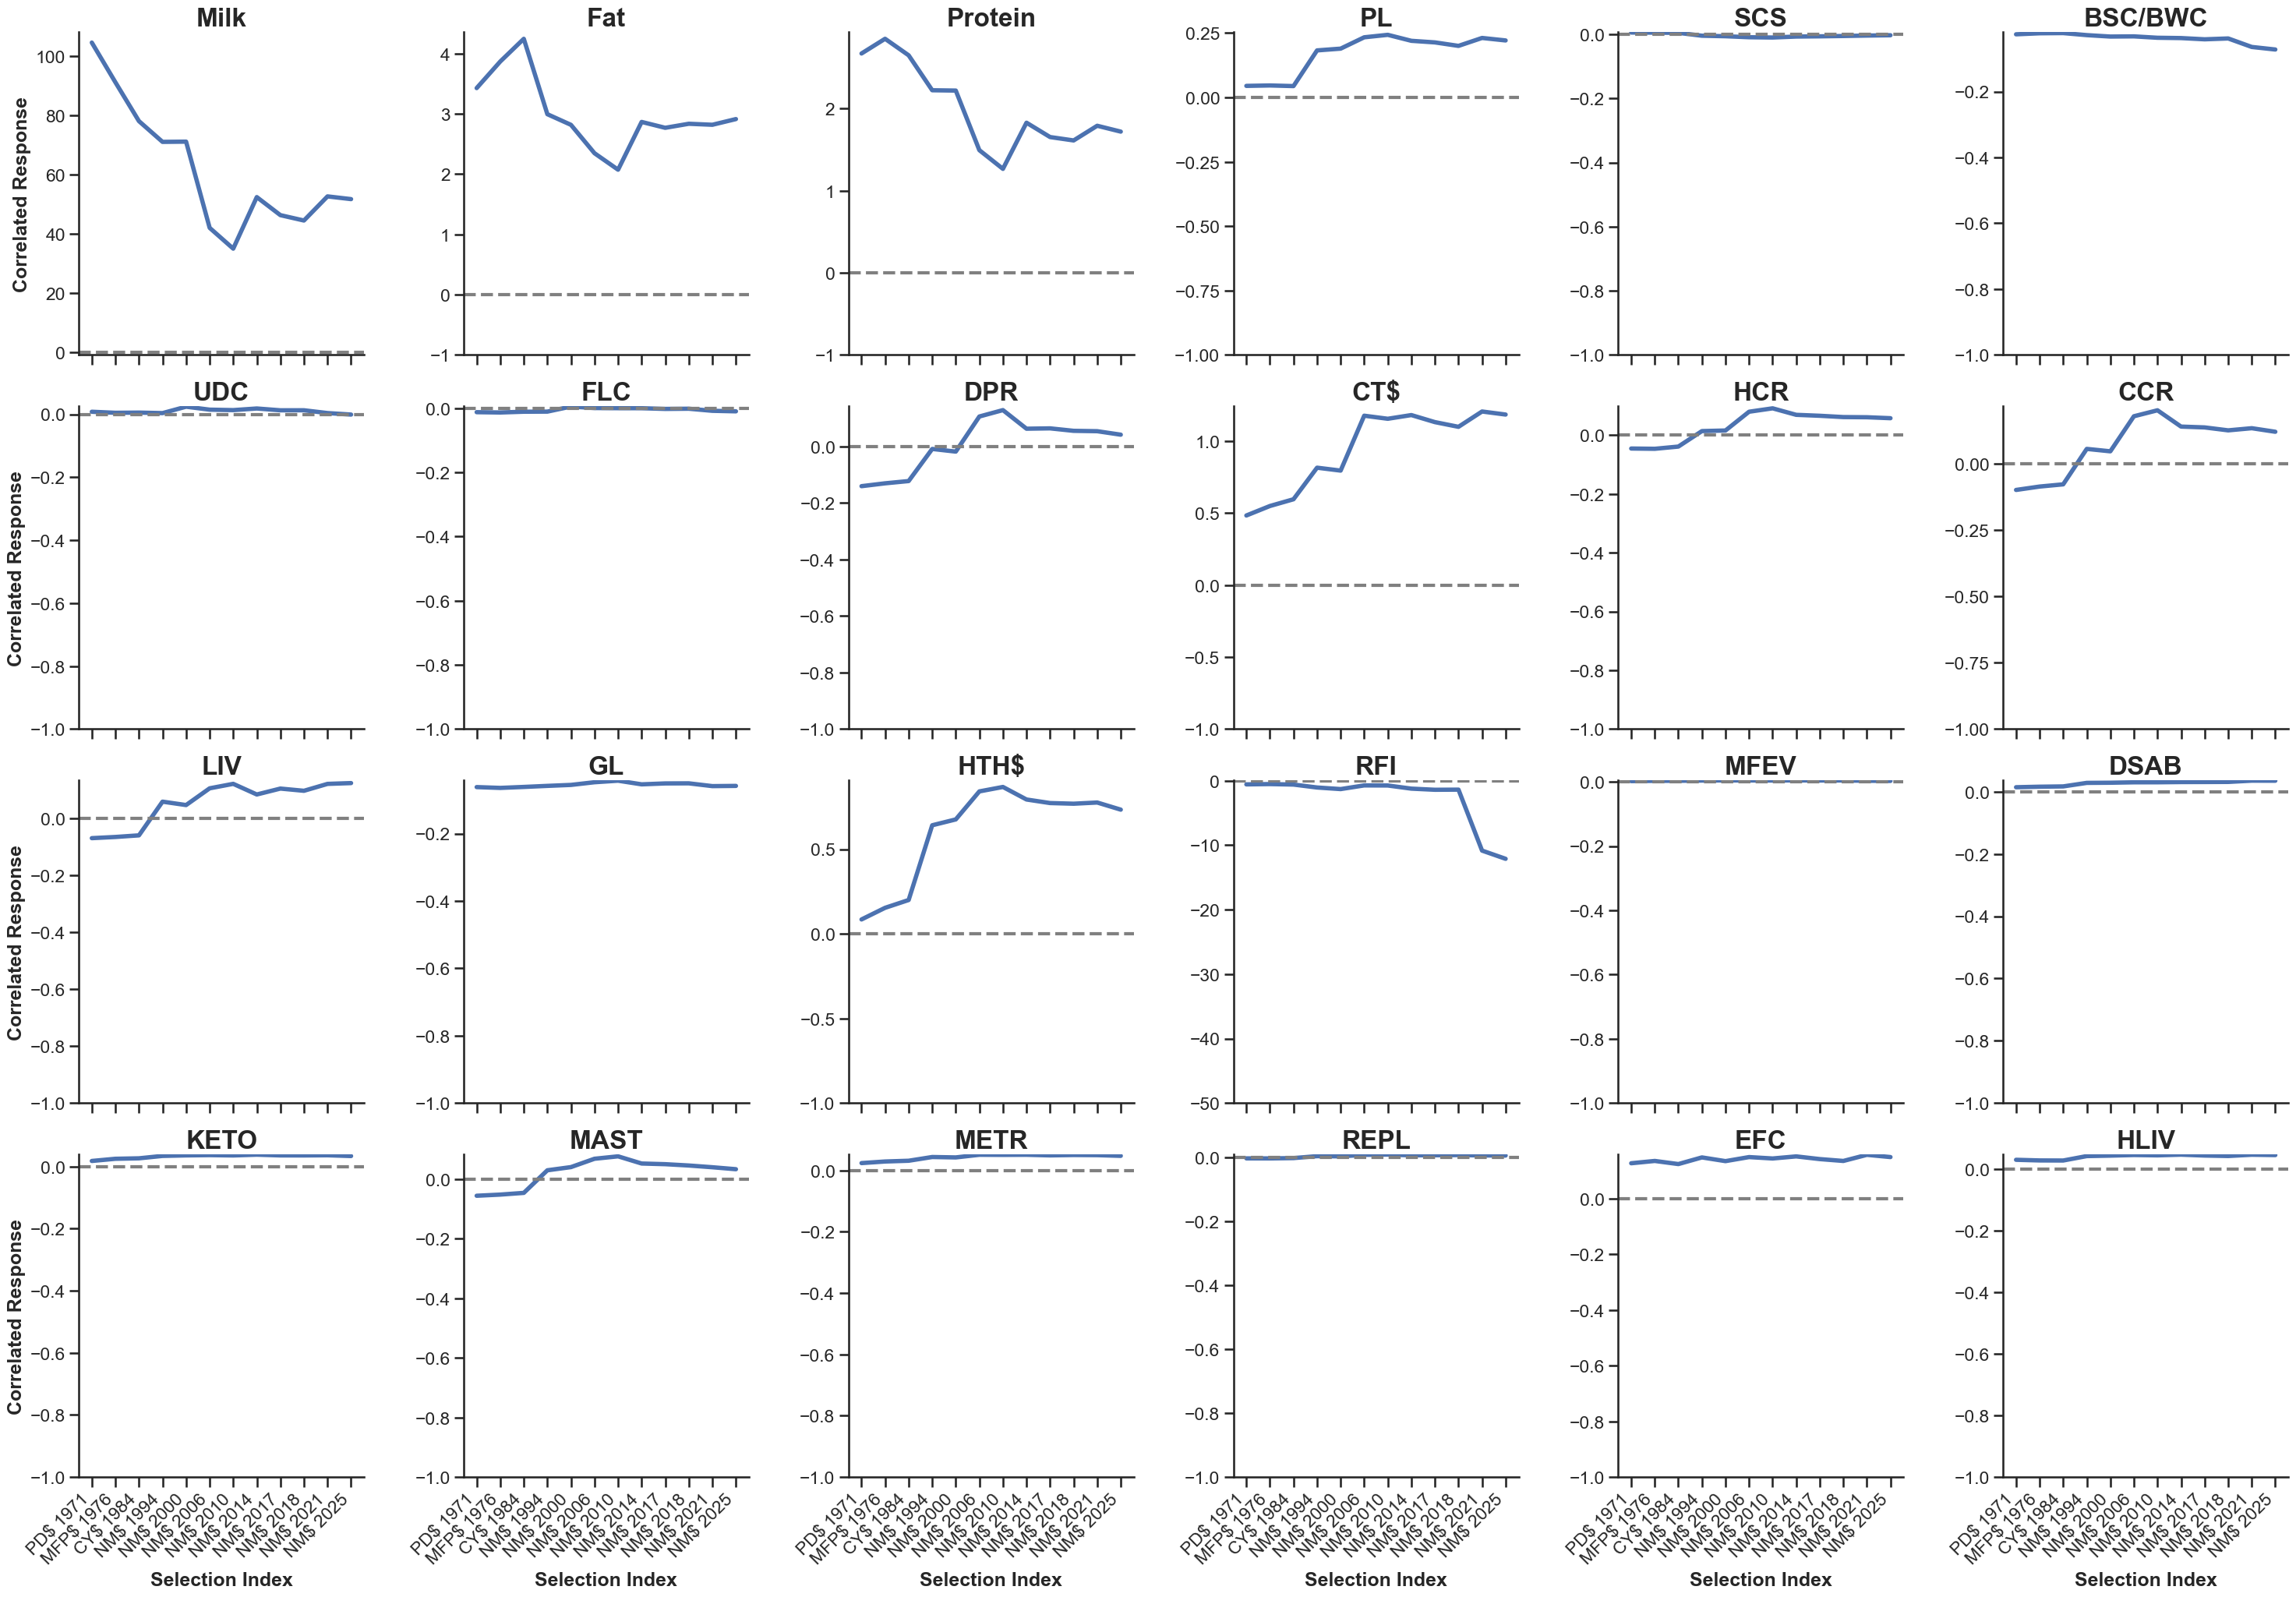

In [971]:
sns.set_style("white")
sns.set_style("ticks")
sns.set_context("talk")
r = sns.relplot(
    data=tall_response, x="Year", y="value",
    col="variable", kind="line", col_wrap=6,
    facet_kws=dict(sharey=False, sharex=True,),
    col_order= [ 'Milk', 'Fat', 'Protein', 'PL', 'SCS', 'BSC/BWC', 'UDC', 'FLC', 'DPR', 'CT$',
                 'HCR', 'CCR', 'LIV', 'GL', 'HTH$', 'RFI', 'MFEV', 'DSAB', 'KETO', 'MAST',
                 'METR', 'REPL', 'EFC', 'HLIV'],
    **{"linewidth": 4,},
)
# Make all figures share a common y-axis minimum.
r.set(ylim=(-1, None))
sns.set(font_scale = 2)

# I want to set all y-axes to a minimum of 0, except for RFI
axes = r.axes
axes[15].set_ylim(-50,)
for ax in axes:
    ax.axhline(0, ls='--', linewidth=3, color='gray')

# Label the axes
r.set_axis_labels("Selection Index", "Correlated Response", fontdict= {'fontweight':'bold'})
# Put the trait name as a title on each subplot.
r.set_titles("{col_name}", fontdict= {'fontweight':'bold'})
r.set_xticklabels(tall_response['Index Name'].unique(), rotation=45, ha="right")
#r.despine()
r.savefig('Cole 2025 Figure 2.png', dpi=600, transparent=True, bbox_inches='tight')

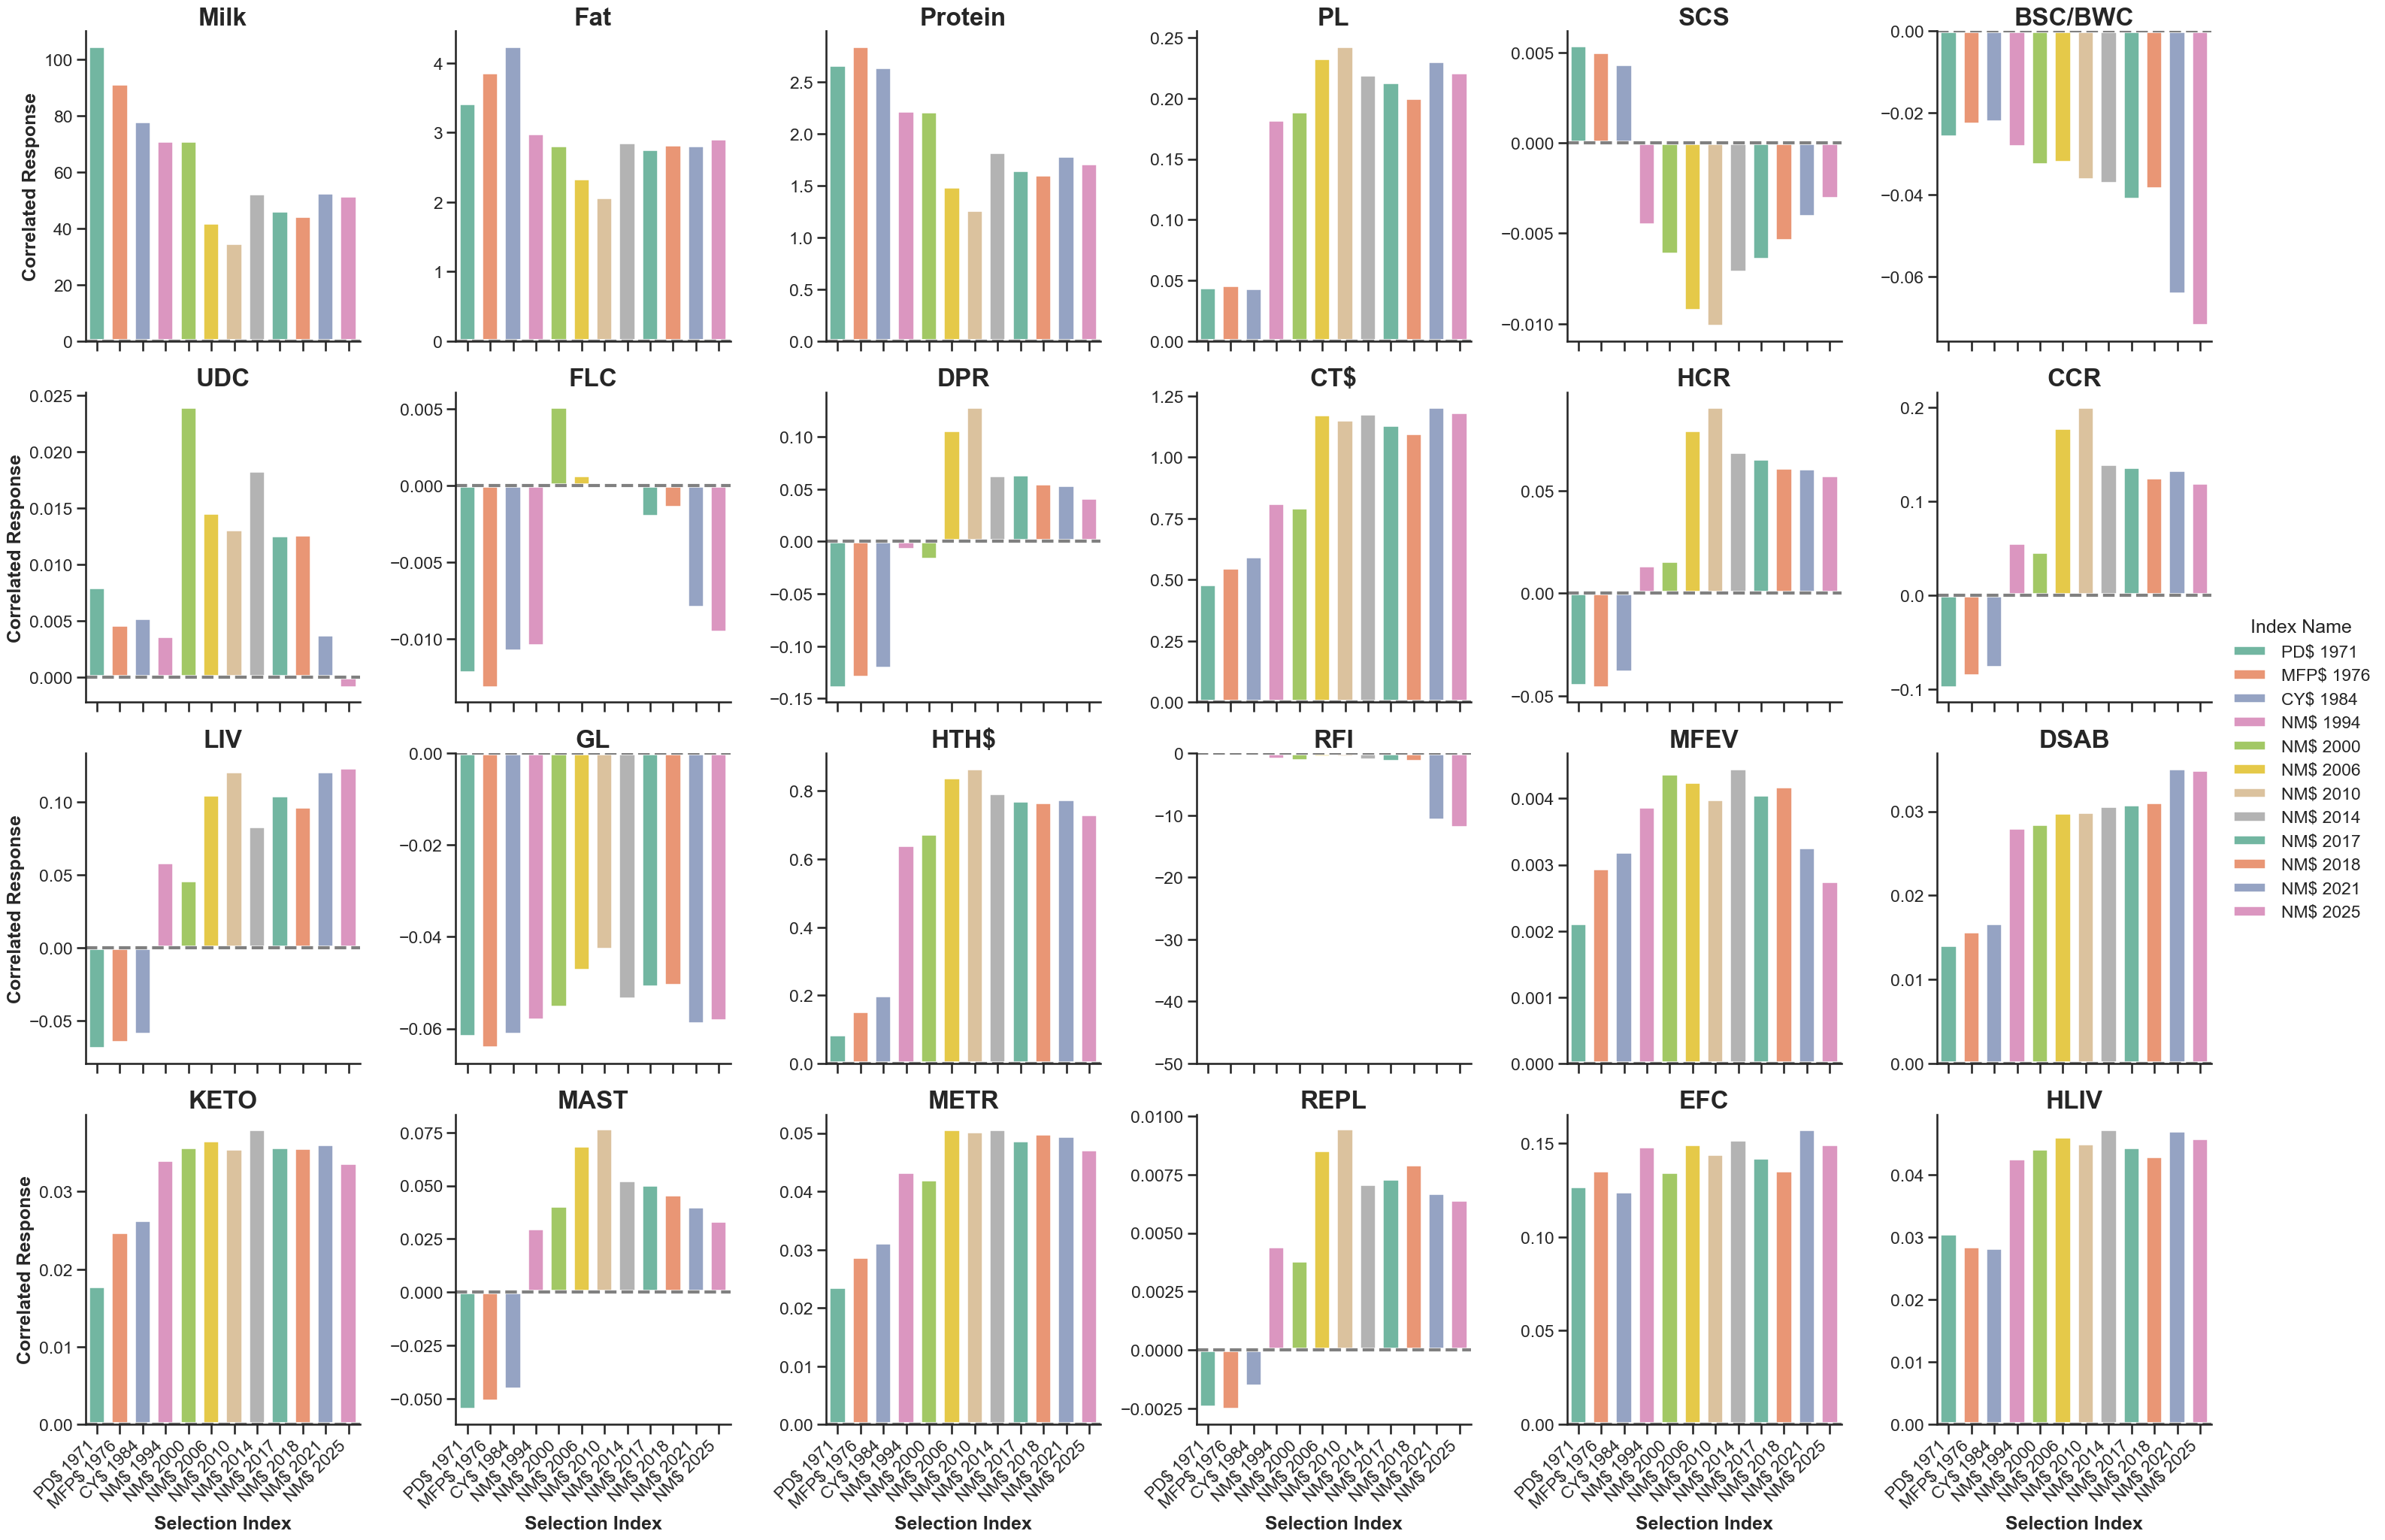

In [972]:
#g = sns.catplot(kind='bar', data=tall_response, x='Year', y='value', col='variable')

sns.set_style("white")
sns.set_style("ticks")
sns.set_context("talk")
r = sns.catplot(
    data=tall_response,
    x="Year",
    y="value",
    col="variable",
    hue="Index Name",
    kind="bar",
    col_wrap=6,
    native_scale=True,
    sharey=False,
    palette="Set2",
    col_order= [ 'Milk', 'Fat', 'Protein', 'PL', 'SCS', 'BSC/BWC', 'UDC', 'FLC', 'DPR', 'CT$',
                 'HCR', 'CCR', 'LIV', 'GL', 'HTH$', 'RFI', 'MFEV', 'DSAB', 'KETO', 'MAST',
                 'METR', 'REPL', 'EFC', 'HLIV'],
    **{"linewidth": 4,},
)
# Make all figures share a common y-axis minimum.
#r.set(ylim=(-1, None))
sns.set(font_scale = 2)

# I want to set all y-axes to a minimum of 0, except for RFI
axes = r.axes
axes[15].set_ylim(-50,)
for ax in axes:
    ax.axhline(0, ls='--', linewidth=3, color='gray')

# Label the axes
r.set_axis_labels("Selection Index", "Correlated Response", fontdict= {'fontweight':'bold'})
# Put the trait name as a title on each subplot.
r.set_titles("{col_name}", fontdict= {'fontweight':'bold'})
r.set_xticklabels(tall_response['Index Name'].unique(), rotation=45, ha="right")
#r.despine()
r.savefig('Cole 2025 Figure 1.png', dpi=600, transparent=True, bbox_inches='tight')

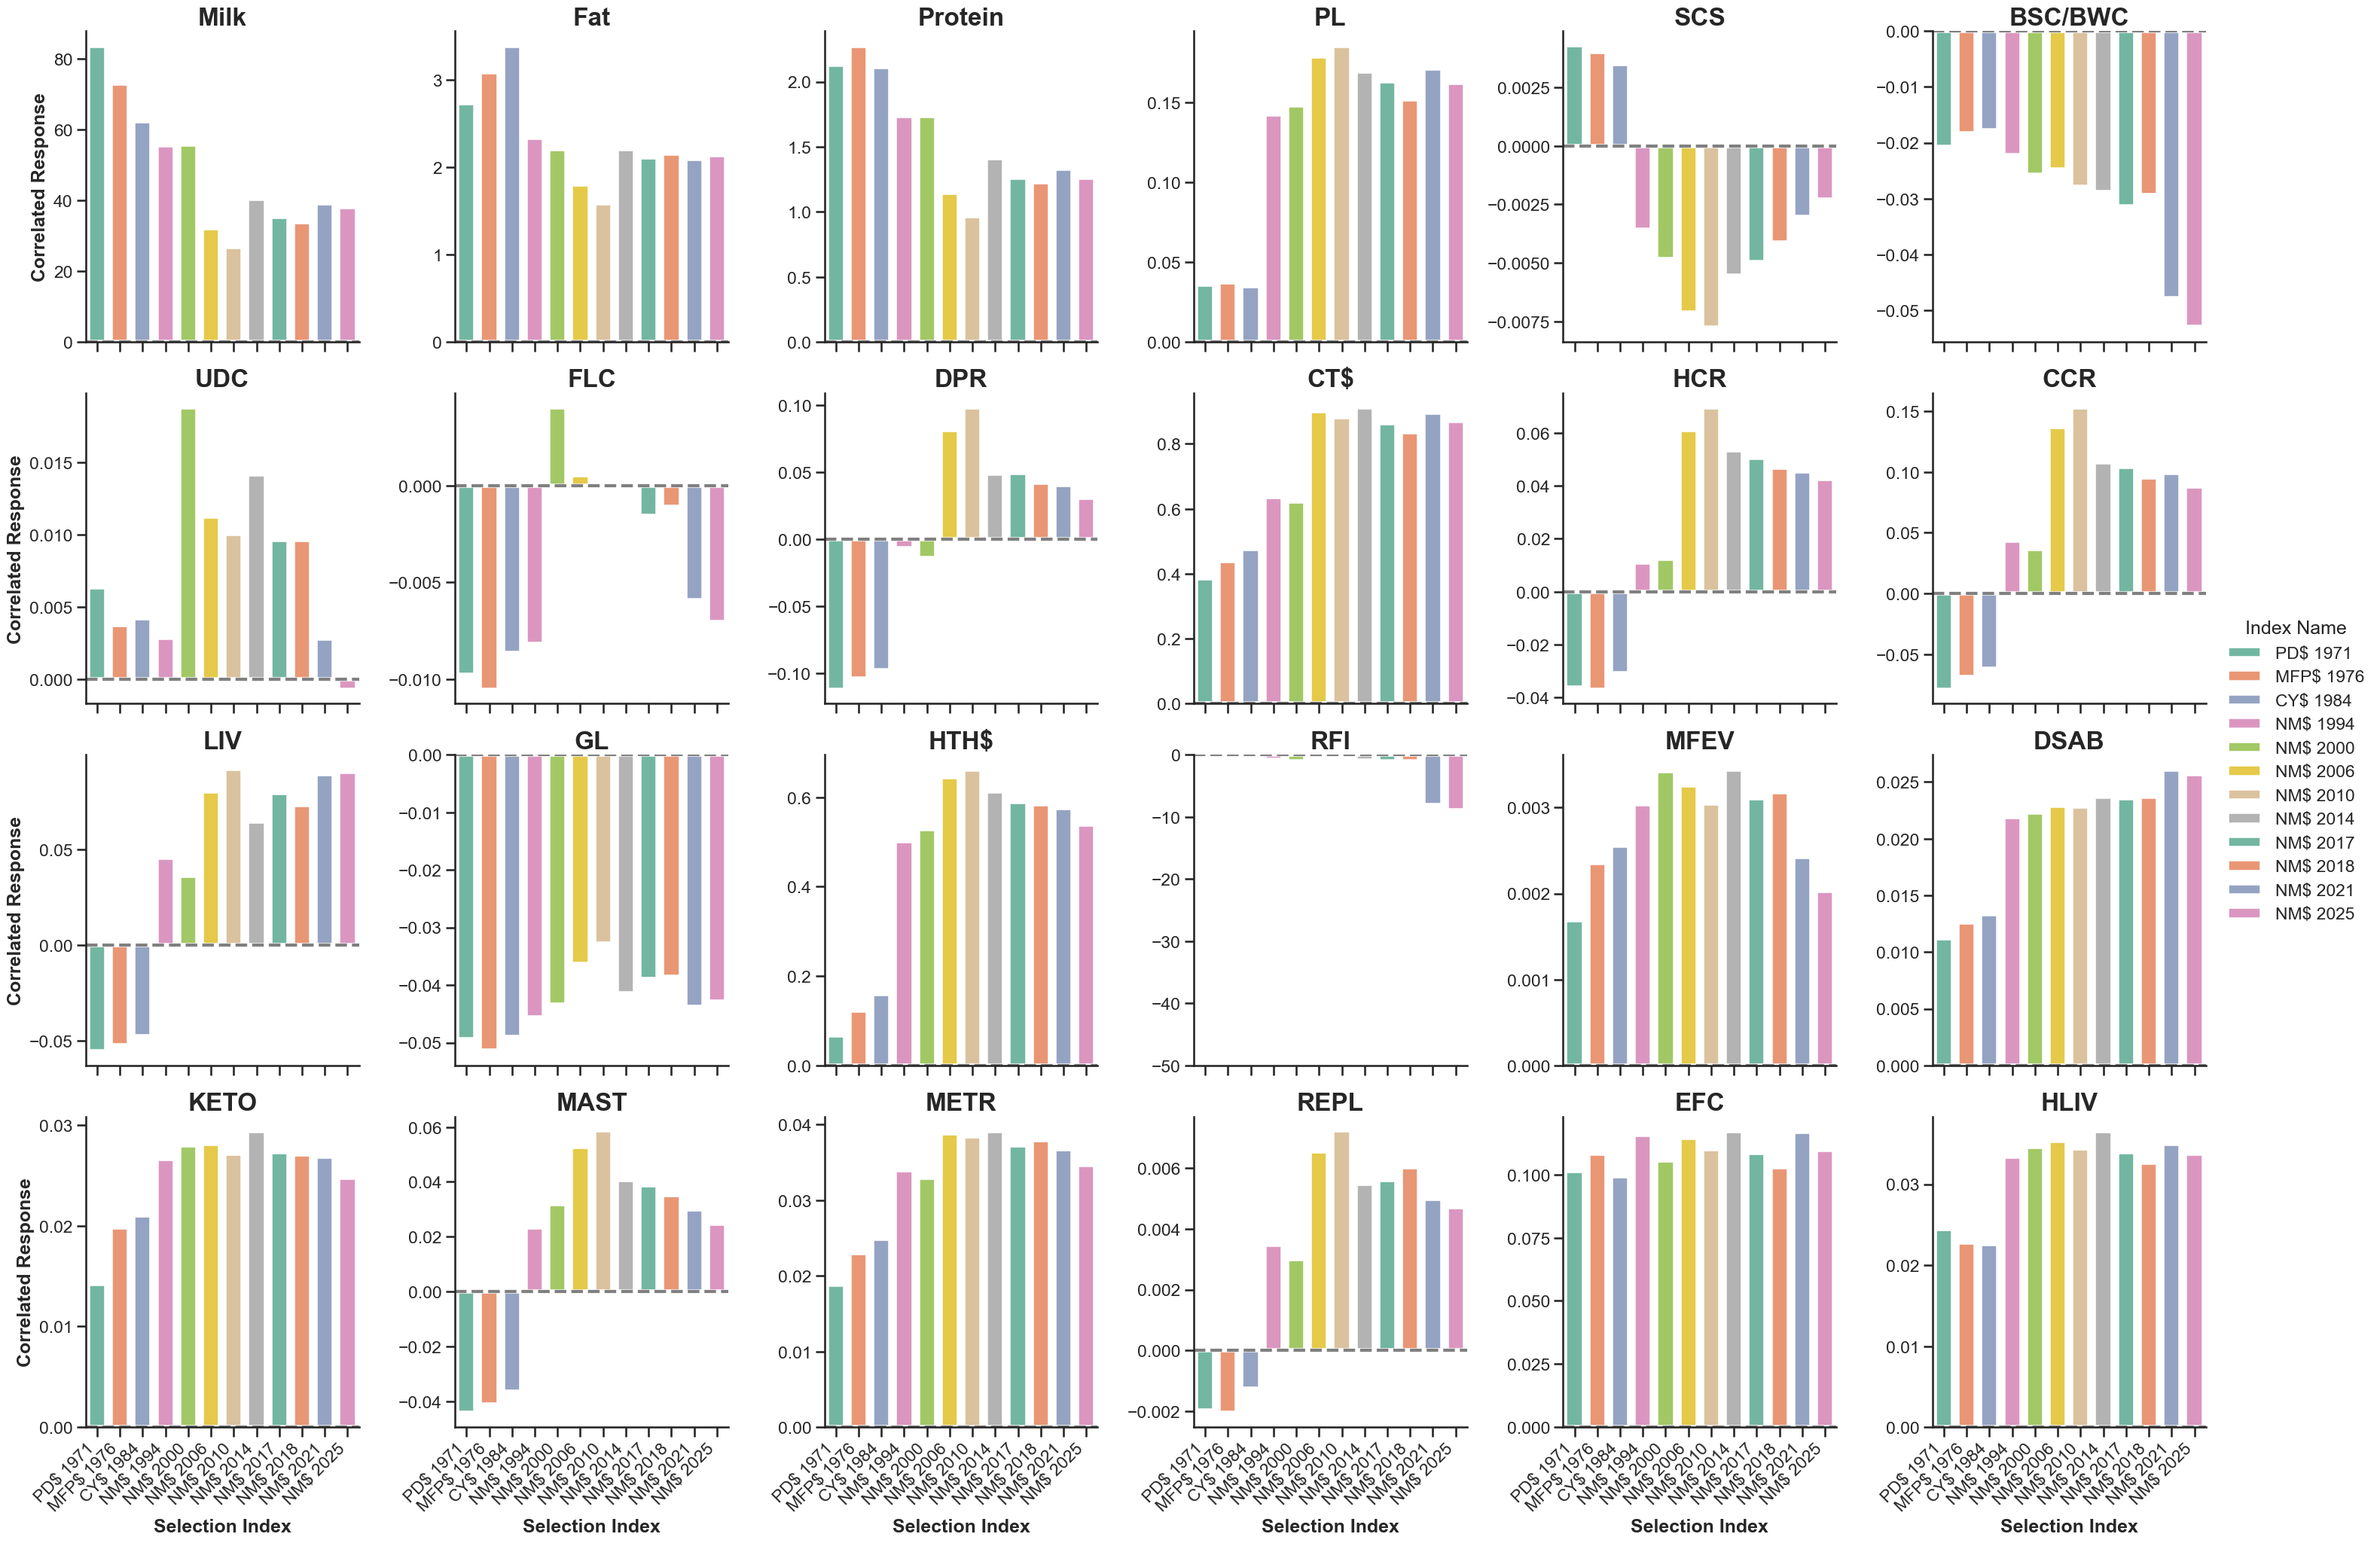

In [973]:
sns.set_style("white")
sns.set_style("ticks")
sns.set_context("talk")
r = sns.catplot(
    data=tall_raw_response,
    x="Year",
    y="value",
    col="variable",
    hue="Index Name",
    kind="bar",
    col_wrap=6,
    native_scale=True,
    sharey=False,
    palette="Set2",
    col_order= [ 'Milk', 'Fat', 'Protein', 'PL', 'SCS', 'BSC/BWC', 'UDC', 'FLC', 'DPR', 'CT$',
                 'HCR', 'CCR', 'LIV', 'GL', 'HTH$', 'RFI', 'MFEV', 'DSAB', 'KETO', 'MAST',
                 'METR', 'REPL', 'EFC', 'HLIV'],
    **{"linewidth": 4,},
)
# Make all figures share a common y-axis minimum.
#r.set(ylim=(-1, None))
sns.set(font_scale = 2)

# I want to set all y-axes to a minimum of 0, except for RFI
axes = r.axes
axes[15].set_ylim(-50,)
for ax in axes:
    ax.axhline(0, ls='--', linewidth=3, color='gray')

# Label the axes
r.set_axis_labels("Selection Index", "Correlated Response", fontdict= {'fontweight':'bold'})
# Put the trait name as a title on each subplot.
r.set_titles("{col_name}", fontdict= {'fontweight':'bold'})
r.set_xticklabels(tall_response['Index Name'].unique(), rotation=45, ha="right")
#r.despine()
r.savefig('Cole 2025 Tall Raw Response.png', dpi=600, transparent=True, bbox_inches='tight')

In [974]:
tall_response.to_csv('Tall Selection Response Using Weighted P Matrix.csv', na_rep=np.NaN, header=True, index=False)
tall_raw_response.to_csv('Tall Selection Response Using Unweighted P Matrix.csv', na_rep=np.NaN, header=True, index=False)

In [975]:
sns.__version__

'0.13.2'

In [976]:
pd.__version__

'2.2.2'

In [977]:
np.__version__

'1.26.4'

In [978]:
!python -V

Python 3.11.7
